# BajetIn — Exploratory Data Analysis



## Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.titleweight"] = "bold"

DATA_DIR = Path("bajetin_data")  

def fmt_rupiah(x, pos=None):
    if x >= 1_000_000:
        return f"Rp {x/1_000_000:.1f}M"
    elif x >= 1_000:
        return f"Rp {x/1_000:.0f}K"
    return f"Rp {x:.0f}"

print("Setup selesai.")


Setup selesai.


## Load Semua Dataset

In [4]:
users       = pd.read_csv("E:/4. Universitas Gadjah Mada/1. S-1 Statistika\SEMESTER 6/3. Coding Camp/4. Capstone Project\Data Science/users.csv", parse_dates=["createdAt"])
tx          = pd.read_csv("E:/4. Universitas Gadjah Mada/1. S-1 Statistika\SEMESTER 6/3. Coding Camp/4. Capstone Project\Data Science/transactions.csv",
                parse_dates=["transactionDate", "createdAt"])
budgets     = pd.read_csv("E:/4. Universitas Gadjah Mada/1. S-1 Statistika\SEMESTER 6/3. Coding Camp/4. Capstone Project\Data Science/budgets.csv")
assess      = pd.read_csv("E:/4. Universitas Gadjah Mada/1. S-1 Statistika\SEMESTER 6/3. Coding Camp/4. Capstone Project\Data Science/financial_assessments.csv",
                parse_dates=["createdAt"])
chat        = pd.read_csv("E:/4. Universitas Gadjah Mada/1. S-1 Statistika\SEMESTER 6/3. Coding Camp/4. Capstone Project\Data Science/chat_messages.csv",
                parse_dates=["createdAt"])
articles    = pd.read_csv("E:/4. Universitas Gadjah Mada/1. S-1 Statistika\SEMESTER 6/3. Coding Camp/4. Capstone Project\Data Science/literacy_articles.csv")
monthly     = pd.read_csv("E:/4. Universitas Gadjah Mada/1. S-1 Statistika\SEMESTER 6/3. Coding Camp/4. Capstone Project\Data Science/user_monthly_summary.csv")
cat_summary = pd.read_csv("E:/4. Universitas Gadjah Mada/1. S-1 Statistika\SEMESTER 6/3. Coding Camp/4. Capstone Project\Data Science/category_spending_summary.csv")
nlp         = pd.read_csv("E:/4. Universitas Gadjah Mada/1. S-1 Statistika\SEMESTER 6/3. Coding Camp/4. Capstone Project\Data Science/nlp_training_dataset.csv")

datasets = {
    "users": users, "transactions": tx, "budgets": budgets,
    "financial_assessments": assess, "chat_messages": chat,
    "literacy_articles": articles, "user_monthly_summary": monthly,
    "category_spending_summary": cat_summary, "nlp_training_dataset": nlp,
}

print(f"{'Dataset':<30} {'Rows':>8} {'Cols':>6}")
print("-" * 46)
for name, df in datasets.items():
    print(f"{name:<30} {len(df):>8,} {df.shape[1]:>6}")


<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:2: SyntaxWarning: invalid escape sequence '\S'
<>:4: SyntaxWarning: invalid escape sequence '\S'
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:7: SyntaxWarning: invalid escape sequence '\S'
<>:9: SyntaxWarning: invalid escape sequence '\S'
<>:10: SyntaxWarning: invalid escape sequence '\S'
<>:11: SyntaxWarning: invalid escape sequence '\S'
<>:12: SyntaxWarning: invalid escape sequence '\S'
<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:2: SyntaxWarning: invalid escape sequence '\S'
<>:4: SyntaxWarning: invalid escape sequence '\S'
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:7: SyntaxWarning: invalid escape sequence '\S'
<>:9: SyntaxWarning: invalid escape sequence '\S'
<>:10: SyntaxWarning: invalid escape sequence '\S'
<>:11: SyntaxWarning: invalid escape sequence '\S'
<>:12: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Hp\AppData\Local\Temp\ipykernel_15176\1172013236.py:1: SyntaxWarning: invalid escape 

Dataset                            Rows   Cols
----------------------------------------------
users                               241      8
transactions                    127,255     12
budgets                          14,985     10
financial_assessments             2,169      7
chat_messages                     2,322      5
literacy_articles                    38      7
user_monthly_summary              2,169     11
category_spending_summary        18,078      9
nlp_training_dataset             75,973     20


---
## 1. Users

### 1.1 Gambaran Umum

In [5]:
print(users.shape)
users.head()


(241, 8)


,id,user_hash,name_masked,email_masked,role,monthlyIncome,currency,createdAt
0,4015130f-0670-41a8-9503-440a9f71dd79,9fdb767e0214,T*** K***,ti****@gmail.com,user,5919141,IDR,2025-06-06 05:08:14.242121
1,d178fbcd-2adc-4360-9825-dcb1ed79c058,57504da566d9,S*** W***,si****@gmail.com,user,5862906,IDR,2025-07-12 23:49:26.242121
2,afdb8bd1-f8a3-4631-99c0-4c903b183011,b5d98af66c0d,B*** S***,ba****@gmail.com,user,3651545,IDR,2025-06-17 13:51:35.242121
3,9e21ba2b-145f-4c7a-bc06-b21613151e20,e73e337e3a77,R*** N***,ra****@gmail.com,user,8415426,IDR,2025-07-06 14:31:14.242121
4,49db3301-f5bf-414b-9d34-26b59241dff6,3b218accc58e,E*** H***,ek****@gmail.com,user,4667335,IDR,2025-07-18 17:52:25.242121


In [6]:
users.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241 entries, 0 to 240
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             241 non-null    object        
 1   user_hash      241 non-null    object        
 2   name_masked    241 non-null    object        
 3   email_masked   241 non-null    object        
 4   role           241 non-null    object        
 5   monthlyIncome  241 non-null    int64         
 6   currency       241 non-null    object        
 7   createdAt      241 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(6)
memory usage: 15.2+ KB


In [7]:
users.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,241,241,4015130f-0670-41a8-9503-440a9f71dd79,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
user_hash,241,241,9fdb767e0214,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name_masked,241,110,S*** S***,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
email_masked,241,36,ri****@gmail.com,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
role,241,2,user,224,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monthlyIncome,241.00,NaN,NaN,NaN,"7,174,102.22","3,323,467.00","4,898,624.00","5,881,316.00","8,362,319.00","20,583,932.00","3,474,129.02"
currency,241,1,IDR,241,NaN,NaN,NaN,NaN,NaN,NaN,NaN
createdAt,241,NaN,NaN,NaN,2025-06-25 03:32:47.598967296,2025-05-16 01:05:32.242121,2025-06-05 07:38:38.242120960,2025-06-23 14:40:46.242120960,2025-07-13 19:48:32.242120960,2025-08-12 23:28:57.242121,NaN


In [8]:
print("Missing values:")
print(users.isnull().sum())
print()
print("Duplikat baris:", users.duplicated().sum())
print("Duplikat id   :", users["id"].duplicated().sum())


Missing values:
id               0
user_hash        0
name_masked      0
email_masked     0
role             0
monthlyIncome    0
currency         0
createdAt        0
dtype: int64

Duplikat baris: 0
Duplikat id   : 0


### 1.2 Distribusi Role

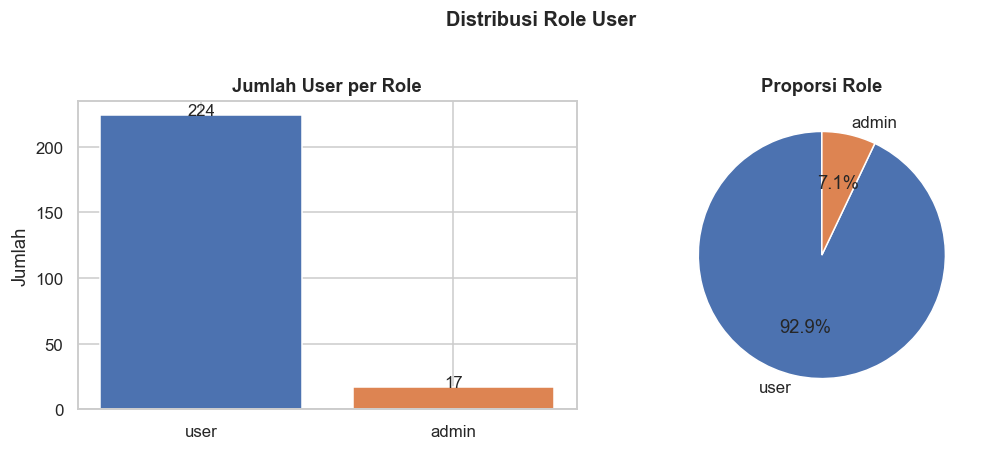

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

role_counts = users["role"].value_counts()
axes[0].bar(role_counts.index, role_counts.values, color=["#4C72B0","#DD8452"])
axes[0].set_title("Jumlah User per Role")
axes[0].set_ylabel("Jumlah")
for i, v in enumerate(role_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha="center", fontsize=11)

axes[1].pie(role_counts.values, labels=role_counts.index,
            autopct="%1.1f%%", startangle=90,
            colors=["#4C72B0","#DD8452"])
axes[1].set_title("Proporsi Role")

plt.suptitle("Distribusi Role User", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### 1.3 Distribusi Monthly Income

C:\Users\Hp\AppData\Local\Temp\ipykernel_15176\3773289600.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_by_role, labels=roles, patch_artist=True,


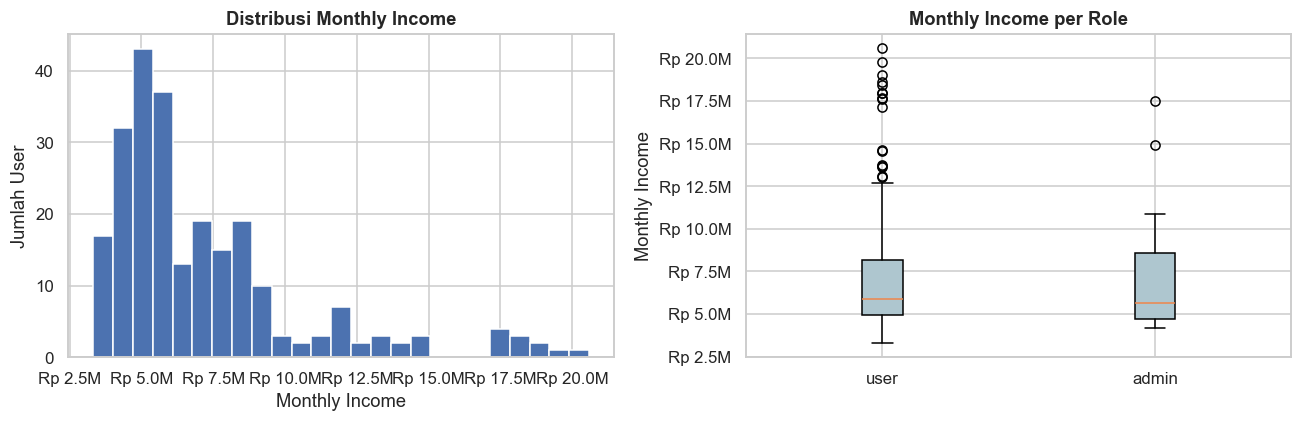

count           Rp 241
mean      Rp 7,174,102
std       Rp 3,474,129
min       Rp 3,323,467
25%       Rp 4,898,624
50%       Rp 5,881,316
75%       Rp 8,362,319
max      Rp 20,583,932
Name: monthlyIncome, dtype: object


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(users["monthlyIncome"], bins=25, color="#4C72B0", edgecolor="white")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_rupiah))
axes[0].set_title("Distribusi Monthly Income")
axes[0].set_xlabel("Monthly Income")
axes[0].set_ylabel("Jumlah User")

# Box plot per role
roles = users["role"].unique()
data_by_role = [users[users["role"] == r]["monthlyIncome"].values for r in roles]
axes[1].boxplot(data_by_role, labels=roles, patch_artist=True,
                boxprops=dict(facecolor="#AEC6CF"))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_rupiah))
axes[1].set_title("Monthly Income per Role")
axes[1].set_ylabel("Monthly Income")

plt.tight_layout()
plt.show()

print(users["monthlyIncome"].describe().apply(lambda x: f"Rp {x:,.0f}"))


### 1.4 Tren Registrasi User

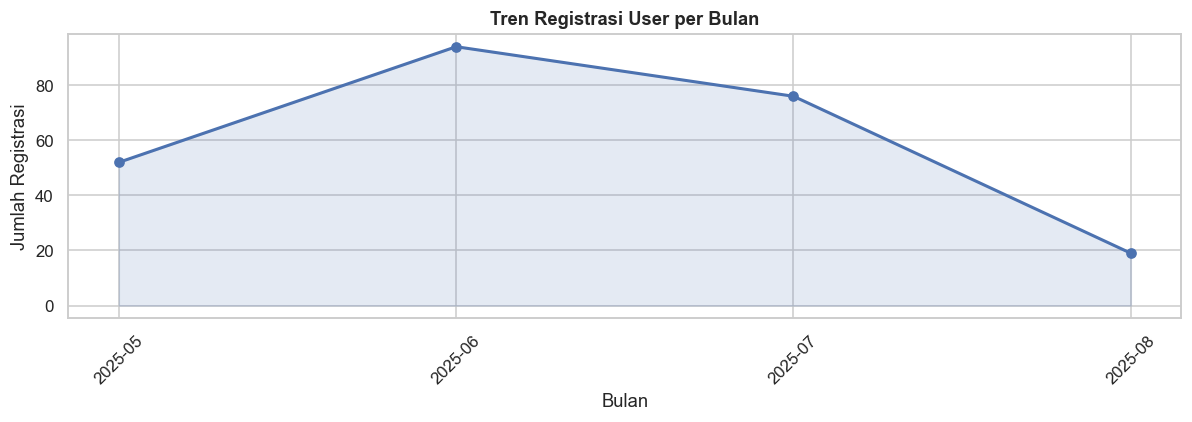

In [11]:
users["reg_month"] = users["createdAt"].dt.to_period("M")
reg_trend = users.groupby("reg_month").size()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(reg_trend.index.astype(str), reg_trend.values,
        marker="o", linewidth=2, color="#4C72B0")
ax.fill_between(reg_trend.index.astype(str), reg_trend.values,
                alpha=0.15, color="#4C72B0")
ax.set_title("Tren Registrasi User per Bulan")
ax.set_xlabel("Bulan")
ax.set_ylabel("Jumlah Registrasi")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


---
## 2. Transactions

### 2.1 Gambaran Umum

In [12]:
print(tx.shape)
tx.head()


(127255, 12)


,id,userId,title,amount,type,category,note,source,confidence,transactionDate,createdAt,period
0,19a76954-02e1-46bd-979b-eebea3fc3499,4015130f-0670-41a8-9503-440a9f71dd79,Gaji ke-13,5929998,income,Lainnya,NaN,manual,NaN,2025-08-02,2025-08-02 00:00:00,2025-08
1,0eb1f13f-ed74-407c-bcc4-51e937e643e3,4015130f-0670-41a8-9503-440a9f71dd79,Jajan bakso,35942,expense,Makanan,15k buat kopi,nlp,0.73,2025-08-27,2025-08-27 19:01:19,2025-08
2,0bceab4f-484e-4b3f-8a71-1320dc9d677b,4015130f-0670-41a8-9503-440a9f71dd79,Beli gorengan,49974,expense,Makanan,NaN,manual,NaN,2025-08-20,2025-08-20 15:54:52,2025-08
3,c0303dee-d056-4e59-856d-18b21b4716da,4015130f-0670-41a8-9503-440a9f71dd79,Makan di food court mall,48246,expense,Makanan,kopi susu lg,nlp,0.80,2025-08-21,2025-08-21 23:28:23,2025-08
4,d29242d5-125e-4ecd-983e-7e5e54b1b1c5,4015130f-0670-41a8-9503-440a9f71dd79,Indomie rebus warung,22076,expense,Makanan,kopi susu lg,nlp,0.74,2025-08-21,2025-08-21 20:27:55,2025-08


In [13]:
tx.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127255 entries, 0 to 127254
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   id               127255 non-null  object        
 1   userId           127255 non-null  object        
 2   title            127255 non-null  object        
 3   amount           127255 non-null  int64         
 4   type             127255 non-null  object        
 5   category         127255 non-null  object        
 6   note             75973 non-null   object        
 7   source           127255 non-null  object        
 8   confidence       75973 non-null   float64       
 9   transactionDate  127255 non-null  datetime64[ns]
 10  createdAt        127255 non-null  datetime64[ns]
 11  period           127255 non-null  object        
dtypes: datetime64[ns](2), float64(1), int64(1), object(8)
memory usage: 11.7+ MB


In [14]:
print("Missing values:")
print(tx.isnull().sum())


Missing values:
id                     0
userId                 0
title                  0
amount                 0
type                   0
category               0
note               51282
source                 0
confidence         51282
transactionDate        0
createdAt              0
period                 0
dtype: int64


### 2.2 Distribusi Type & Source

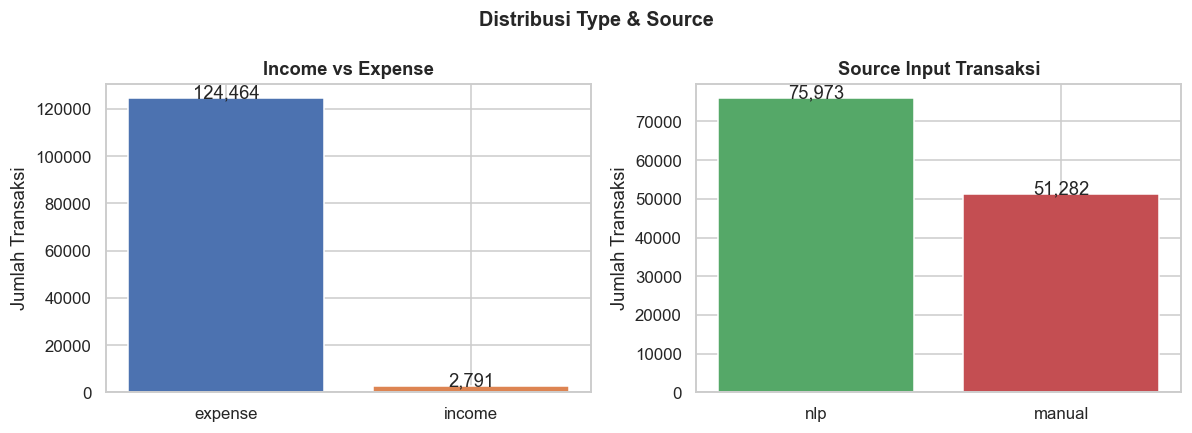

      type  source  count
0  expense     nlp  74883
1  expense  manual  49581
2   income  manual   1701
3   income     nlp   1090


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

type_counts = tx["type"].value_counts()
axes[0].bar(type_counts.index, type_counts.values,
            color=["#4C72B0","#DD8452"])
axes[0].set_title("Income vs Expense")
axes[0].set_ylabel("Jumlah Transaksi")
for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 50, f"{v:,}", ha="center")

source_counts = tx["source"].value_counts()
axes[1].bar(source_counts.index, source_counts.values,
            color=["#55A868","#C44E52"])
axes[1].set_title("Source Input Transaksi")
axes[1].set_ylabel("Jumlah Transaksi")
for i, v in enumerate(source_counts.values):
    axes[1].text(i, v + 50, f"{v:,}", ha="center")

plt.suptitle("Distribusi Type & Source", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(tx[["type","source"]].value_counts().reset_index(name="count"))


### 2.3 Distribusi Amount

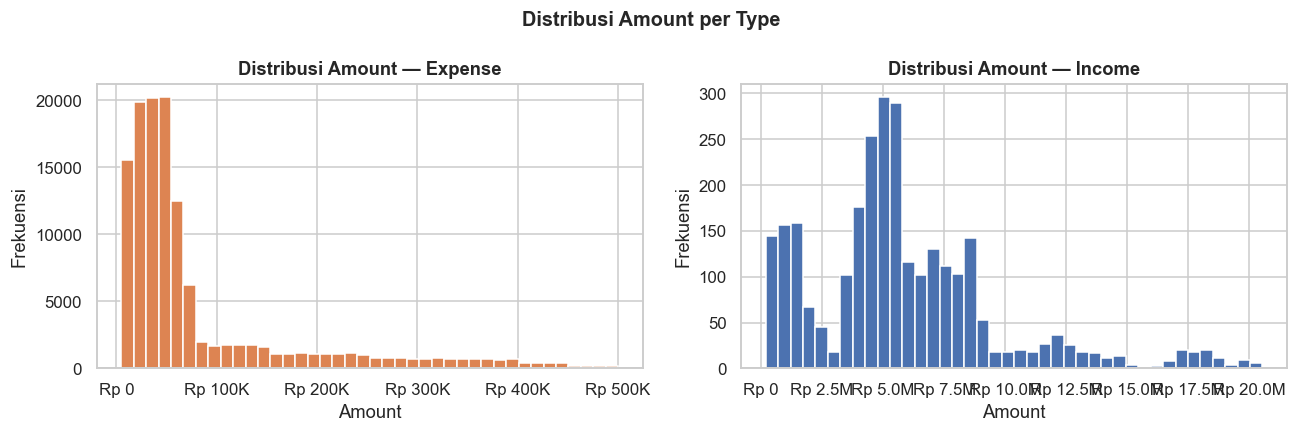

              count          mean           std         min           25%  \
type                                                                        
expense  Rp 124,464     Rp 82,591     Rp 97,101    Rp 5,005     Rp 27,145   
income     Rp 2,791  Rp 5,814,975  Rp 3,849,247  Rp 200,399  Rp 3,785,371   

                  50%           75%            max  
type                                                
expense     Rp 46,227     Rp 76,935     Rp 499,987  
income   Rp 5,238,863  Rp 7,482,800  Rp 20,533,890  


C:\Users\Hp\AppData\Local\Temp\ipykernel_15176\4185833488.py:15: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(tx.groupby("type")["amount"].describe().applymap(lambda x: f"Rp {x:,.0f}"))


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, t, color in zip(axes, ["expense","income"], ["#DD8452","#4C72B0"]):
    data = tx[tx["type"] == t]["amount"]
    ax.hist(data, bins=40, color=color, edgecolor="white")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_rupiah))
    ax.set_title(f"Distribusi Amount — {t.capitalize()}")
    ax.set_xlabel("Amount")
    ax.set_ylabel("Frekuensi")

plt.suptitle("Distribusi Amount per Type", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(tx.groupby("type")["amount"].describe().applymap(lambda x: f"Rp {x:,.0f}"))


### 2.4 Pengeluaran per Kategori

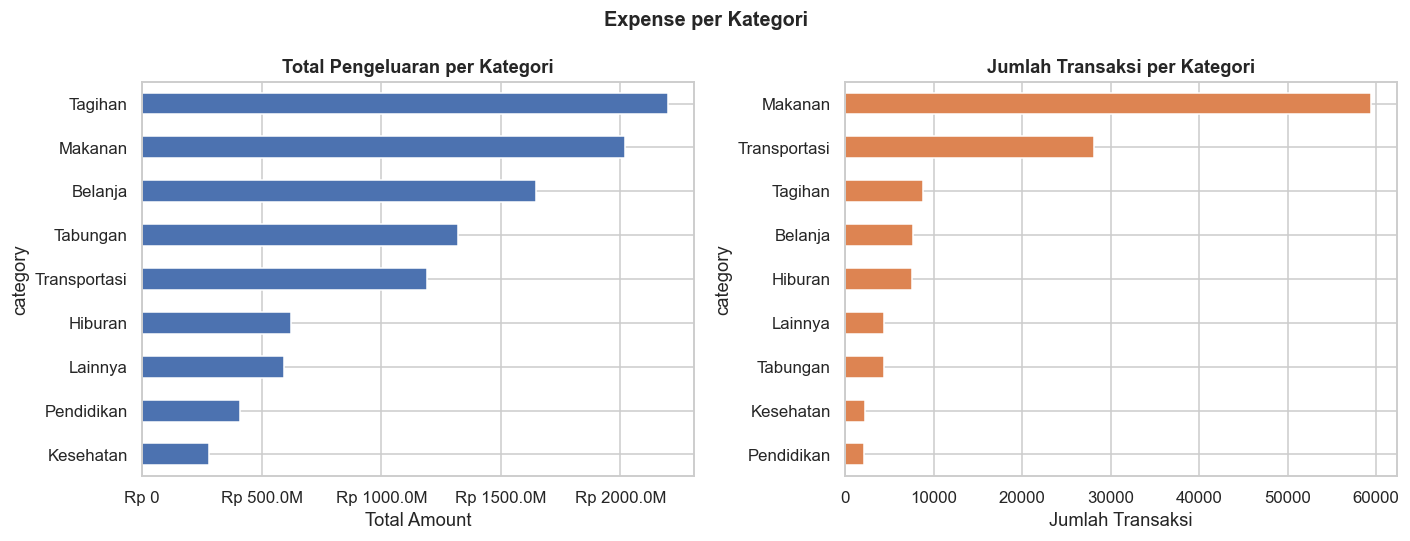

In [17]:
cat_total = (tx[tx["type"] == "expense"]
             .groupby("category")["amount"]
             .sum()
             .sort_values(ascending=True))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cat_total.plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_rupiah))
axes[0].set_title("Total Pengeluaran per Kategori")
axes[0].set_xlabel("Total Amount")

cat_count = (tx[tx["type"] == "expense"]
             .groupby("category")
             .size()
             .sort_values(ascending=True))
cat_count.plot(kind="barh", ax=axes[1], color="#DD8452")
axes[1].set_title("Jumlah Transaksi per Kategori")
axes[1].set_xlabel("Jumlah Transaksi")

plt.suptitle("Expense per Kategori", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### 2.5 Tren Transaksi per Bulan

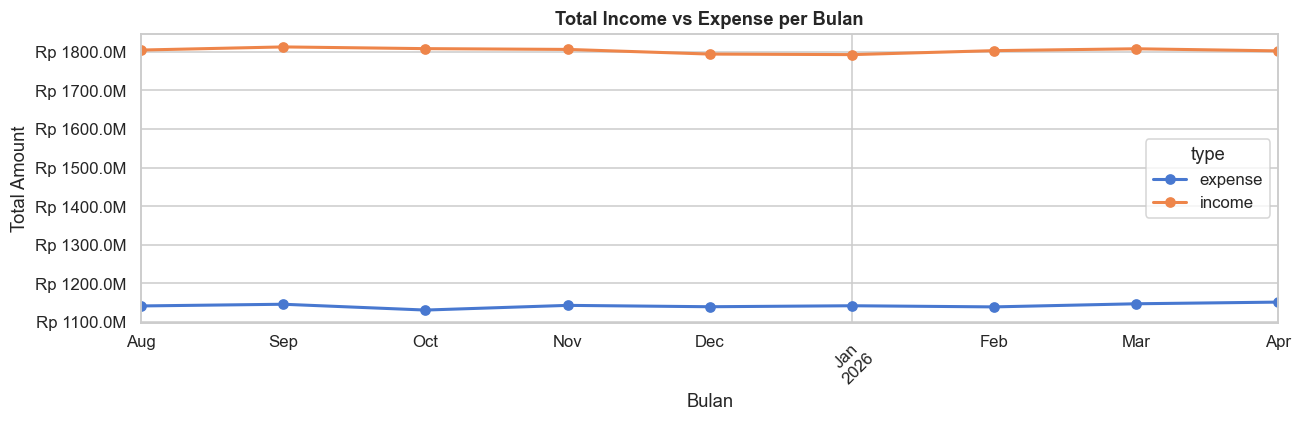

In [18]:
tx["month_period"] = tx["transactionDate"].dt.to_period("M")
monthly_tx = tx.groupby(["month_period","type"])["amount"].sum().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 4))
monthly_tx.plot(ax=ax, marker="o", linewidth=2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_rupiah))
ax.set_title("Total Income vs Expense per Bulan")
ax.set_xlabel("Bulan")
ax.set_ylabel("Total Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 2.6 Distribusi Confidence (NLP)

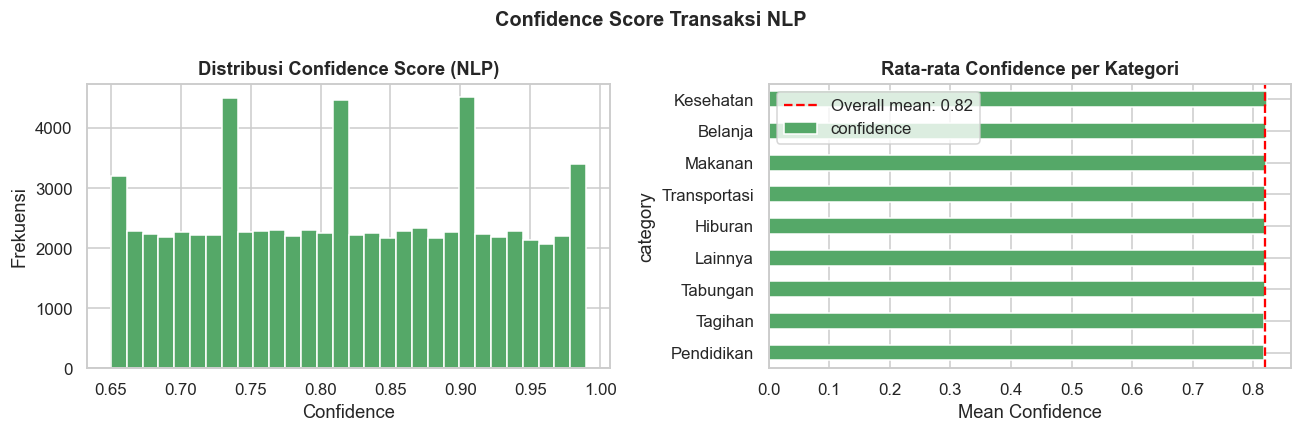

count   75,973.00
mean         0.82
std          0.10
min          0.65
25%          0.74
50%          0.82
75%          0.90
max          0.99
Name: confidence, dtype: float64


In [19]:
nlp_tx = tx[tx["source"] == "nlp"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(nlp_tx["confidence"].dropna(), bins=30,
             color="#55A868", edgecolor="white")
axes[0].set_title("Distribusi Confidence Score (NLP)")
axes[0].set_xlabel("Confidence")
axes[0].set_ylabel("Frekuensi")

# Confidence per kategori
conf_cat = nlp_tx.groupby("category")["confidence"].mean().sort_values()
conf_cat.plot(kind="barh", ax=axes[1], color="#55A868")
axes[1].set_title("Rata-rata Confidence per Kategori")
axes[1].set_xlabel("Mean Confidence")
axes[1].axvline(nlp_tx["confidence"].mean(), color="red",
                linestyle="--", label=f"Overall mean: {nlp_tx['confidence'].mean():.2f}")
axes[1].legend()

plt.suptitle("Confidence Score Transaksi NLP", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(nlp_tx["confidence"].describe())


### 2.7 Jumlah Transaksi per User

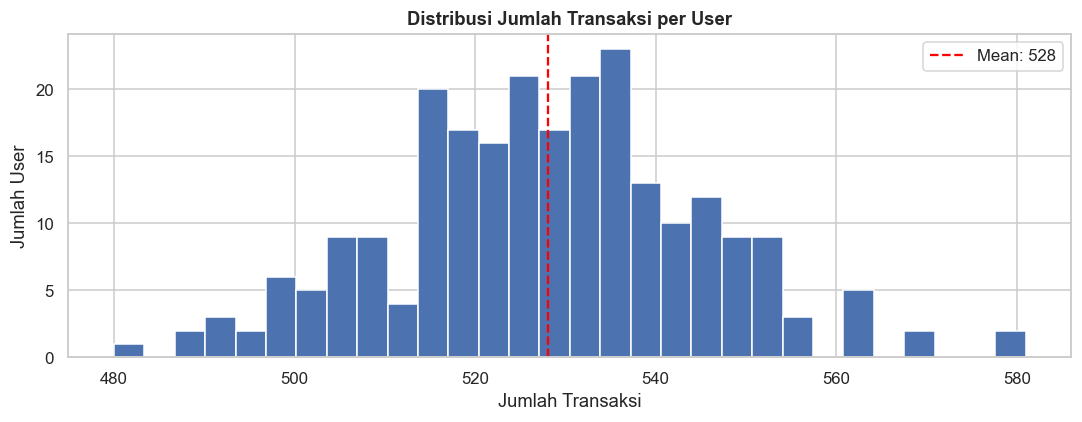

count   241.00
mean    528.03
std      16.98
min     480.00
25%     517.00
50%     529.00
75%     538.00
max     581.00
dtype: float64


In [20]:
tx_per_user = tx.groupby("userId").size()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(tx_per_user, bins=30, color="#4C72B0", edgecolor="white")
ax.set_title("Distribusi Jumlah Transaksi per User")
ax.set_xlabel("Jumlah Transaksi")
ax.set_ylabel("Jumlah User")
ax.axvline(tx_per_user.mean(), color="red", linestyle="--",
           label=f"Mean: {tx_per_user.mean():.0f}")
ax.legend()
plt.tight_layout()
plt.show()

print(tx_per_user.describe())


---
## 3. Budgets

### 3.1 Gambaran Umum

In [21]:
print(budgets.shape)
budgets.head()


(14985, 10)


,id,userId,category,limitAmount,spentAmount,remainingAmount,usagePercent,budgetStatus,month,year
0,b5b3c4a7-79eb-4542-956a-0a42a83c1ab8,4015130f-0670-41a8-9503-440a9f71dd79,Tabungan,1038731,213898,824833,20.60,safe,8,2025
1,89fce881-bf94-4c12-9c5d-deb0912731d5,4015130f-0670-41a8-9503-440a9f71dd79,Belanja,581702,664954,0,114.30,over,8,2025
2,baf6d85c-d7b4-46a7-8fe8-f650d710cd6e,4015130f-0670-41a8-9503-440a9f71dd79,Tagihan,1051761,1187843,0,112.90,over,8,2025
3,c8f77ba3-68ed-4222-93e9-b4511a4632fe,4015130f-0670-41a8-9503-440a9f71dd79,Kesehatan,925775,0,925775,0.00,safe,8,2025
4,90083f70-89a4-4b11-b8e9-701baabb4fbf,4015130f-0670-41a8-9503-440a9f71dd79,Hiburan,500375,412748,87627,82.50,warning,8,2025


In [22]:
print("Missing values:")
print(budgets.isnull().sum())
print()
budgets.describe().T


Missing values:
id                 0
userId             0
category           0
limitAmount        0
spentAmount        0
remainingAmount    0
usagePercent       0
budgetStatus       0
month              0
year               0
dtype: int64



,count,mean,std,min,25%,50%,75%,max
limitAmount,"14,985.00","998,328.41","703,999.65","105,796.00","511,473.00","848,595.00","1,253,700.00","5,129,651.00"
spentAmount,"14,985.00","532,609.16","378,167.03",0.00,"230,306.00","454,123.00","808,483.00","1,990,403.00"
remainingAmount,"14,985.00","565,931.02","692,689.41",0.00,0.00,"361,910.00","842,845.00","4,948,731.00"
usagePercent,"14,985.00",84.83,99.93,0.00,23.00,53.40,108.00,"1,029.10"
month,"14,985.00",6.67,3.94,1.00,3.00,8.00,10.00,12.00
year,"14,985.00","2,025.44",0.50,"2,025.00","2,025.00","2,025.00","2,026.00","2,026.00"


### 3.2 Distribusi Budget Status

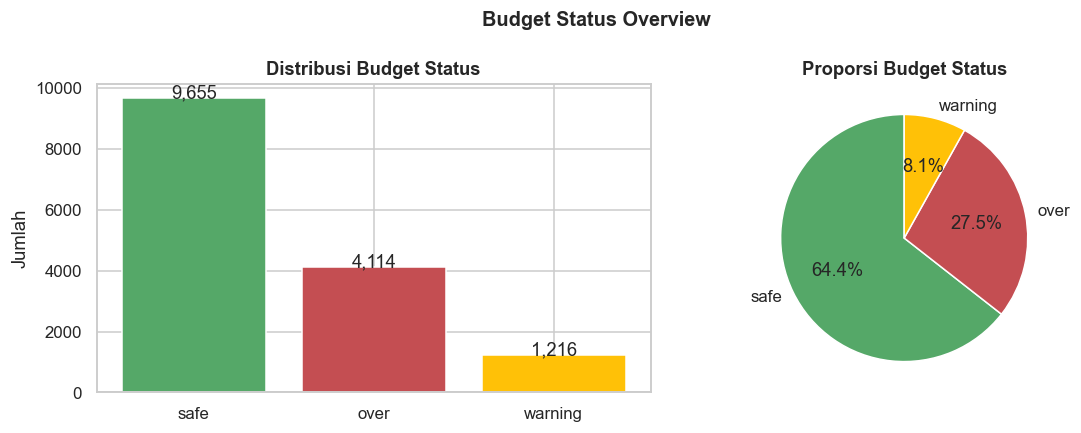

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

status_counts = budgets["budgetStatus"].value_counts()
colors = {"safe": "#55A868", "warning": "#FFC107", "over": "#C44E52"}
bar_colors = [colors[s] for s in status_counts.index]

axes[0].bar(status_counts.index, status_counts.values, color=bar_colors)
axes[0].set_title("Distribusi Budget Status")
axes[0].set_ylabel("Jumlah")
for i, v in enumerate(status_counts.values):
    axes[0].text(i, v + 10, f"{v:,}", ha="center")

axes[1].pie(status_counts.values, labels=status_counts.index,
            autopct="%1.1f%%", colors=bar_colors, startangle=90)
axes[1].set_title("Proporsi Budget Status")

plt.suptitle("Budget Status Overview", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### 3.3 Budget Status per Kategori

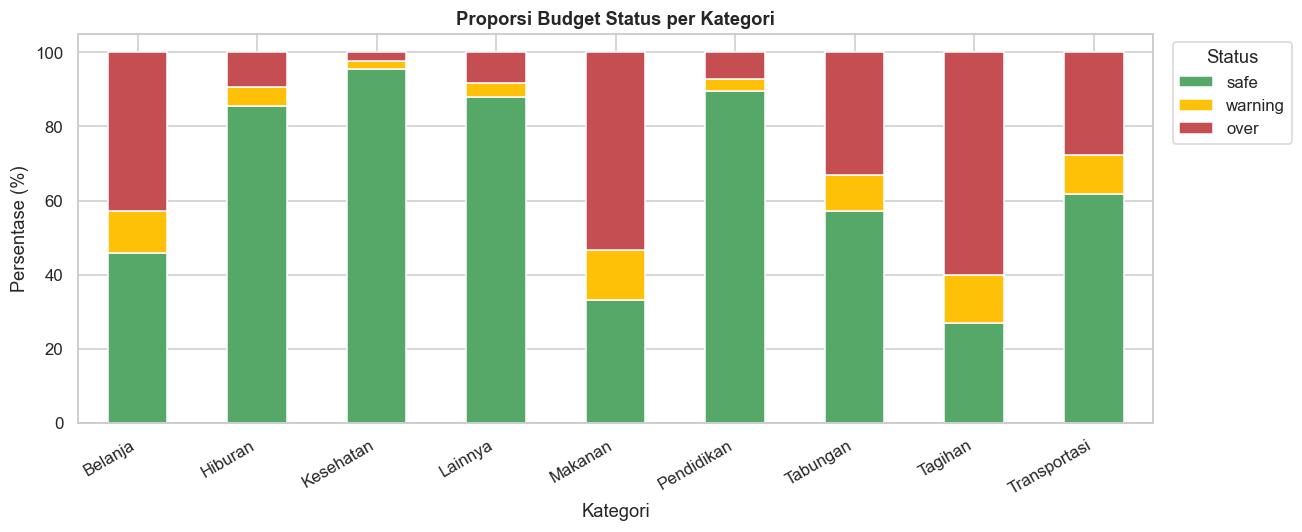

In [24]:
pivot = (budgets.groupby(["category","budgetStatus"])
         .size()
         .unstack(fill_value=0))

pivot = pivot.reindex(columns=["safe","warning","over"], fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
pivot_pct.plot(kind="bar", ax=ax, stacked=True,
               color=["#55A868","#FFC107","#C44E52"], edgecolor="white")
ax.set_title("Proporsi Budget Status per Kategori")
ax.set_xlabel("Kategori")
ax.set_ylabel("Persentase (%)")
ax.legend(title="Status", bbox_to_anchor=(1.01, 1))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### 3.4 Distribusi Usage Percent

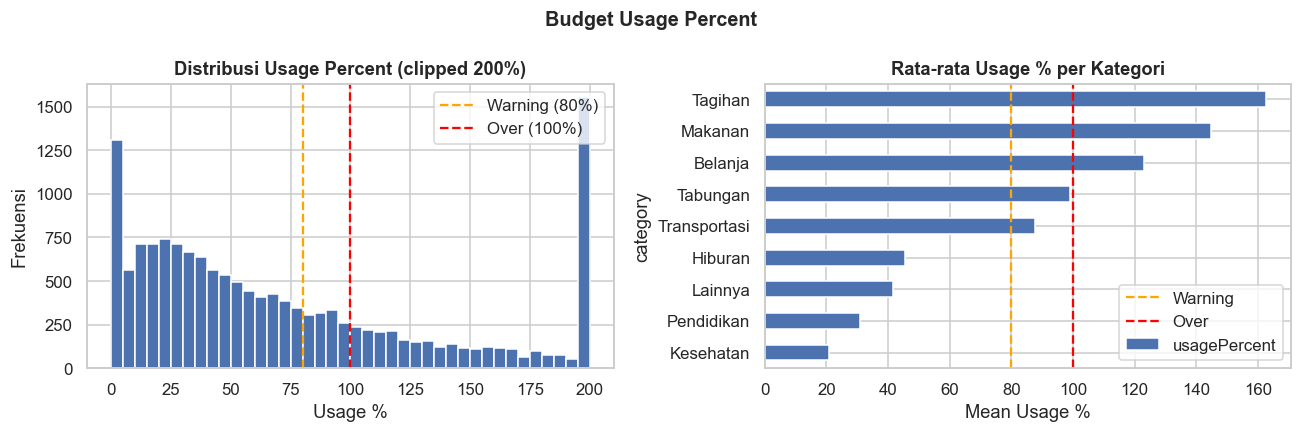

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(budgets["usagePercent"].clip(upper=200), bins=40,
             color="#4C72B0", edgecolor="white")
axes[0].axvline(80, color="orange", linestyle="--", label="Warning (80%)")
axes[0].axvline(100, color="red", linestyle="--", label="Over (100%)")
axes[0].set_title("Distribusi Usage Percent (clipped 200%)")
axes[0].set_xlabel("Usage %")
axes[0].set_ylabel("Frekuensi")
axes[0].legend()

usage_cat = budgets.groupby("category")["usagePercent"].mean().sort_values()
usage_cat.plot(kind="barh", ax=axes[1], color="#4C72B0")
axes[1].axvline(80, color="orange", linestyle="--", label="Warning")
axes[1].axvline(100, color="red", linestyle="--", label="Over")
axes[1].set_title("Rata-rata Usage % per Kategori")
axes[1].set_xlabel("Mean Usage %")
axes[1].legend()

plt.suptitle("Budget Usage Percent", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### 3.5 Limit vs Spent per Kategori

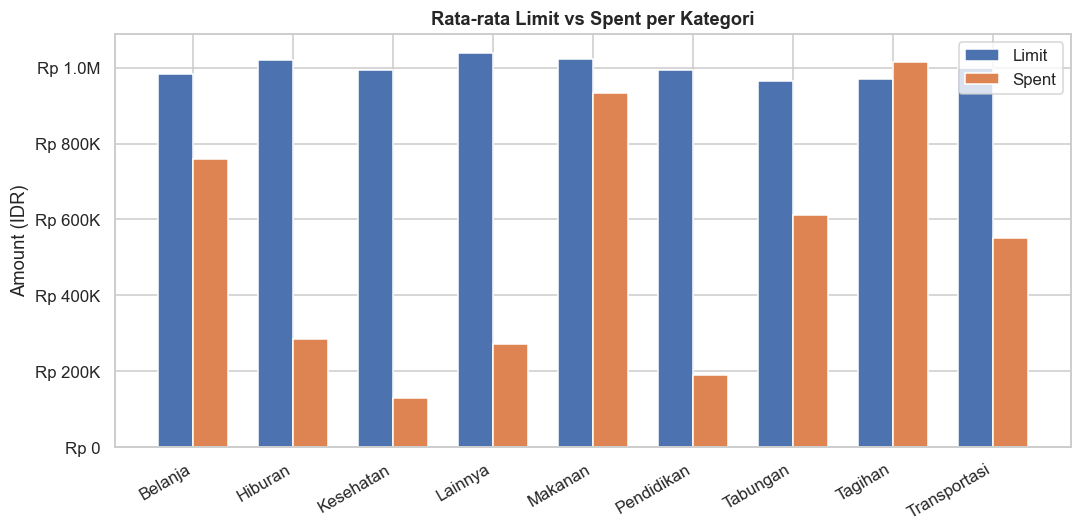

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))

cat_budget = budgets.groupby("category")[["limitAmount","spentAmount"]].mean()
x = range(len(cat_budget))
width = 0.35

ax.bar([i - width/2 for i in x], cat_budget["limitAmount"],
       width, label="Limit", color="#4C72B0")
ax.bar([i + width/2 for i in x], cat_budget["spentAmount"],
       width, label="Spent", color="#DD8452")

ax.set_xticks(list(x))
ax.set_xticklabels(cat_budget.index, rotation=30, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_rupiah))
ax.set_title("Rata-rata Limit vs Spent per Kategori")
ax.set_ylabel("Amount (IDR)")
ax.legend()
plt.tight_layout()
plt.show()


---
## 4. Financial Assessments

### 4.1 Gambaran Umum

In [27]:
print(assess.shape)
assess.head()


(2169, 7)


,id,userId,score,status,answers,recommendation,createdAt
0,5a59df9b-795e-41f6-8018-9f3ebb1f7b54,4015130f-0670-41a8-9503-440a9f71dd79,32,Rentan,{'Apakah kamu memiliki dana darurat minimal 3 ...,Fokus pada pembangunan dana darurat dan kurang...,2025-08-27
1,32c80781-c280-4823-b261-59e21c0b498f,4015130f-0670-41a8-9503-440a9f71dd79,28,Rentan,{'Apakah kamu memiliki dana darurat minimal 3 ...,Fokus pada pembangunan dana darurat dan kurang...,2025-09-26
2,e0632479-0e55-4fe2-803a-f0344345cf49,4015130f-0670-41a8-9503-440a9f71dd79,28,Rentan,{'Apakah kamu memiliki dana darurat minimal 3 ...,Fokus pada pembangunan dana darurat dan kurang...,2025-10-28
3,cae01af4-0d90-4521-9b94-621722908023,4015130f-0670-41a8-9503-440a9f71dd79,25,Rentan,{'Apakah kamu memiliki dana darurat minimal 3 ...,Fokus pada pembangunan dana darurat dan kurang...,2025-11-28
4,b6e5a0f5-9851-47e1-a277-d22f1f0523a0,4015130f-0670-41a8-9503-440a9f71dd79,27,Rentan,{'Apakah kamu memiliki dana darurat minimal 3 ...,Fokus pada pembangunan dana darurat dan kurang...,2025-12-25


In [28]:
print("Missing values:")
print(assess.isnull().sum())
print()
assess[["score"]].describe().T


Missing values:
id                0
userId            0
score             0
status            0
answers           0
recommendation    0
createdAt         0
dtype: int64



,count,mean,std,min,25%,50%,75%,max
score,"2,169.00",56.61,25.02,10.00,34.00,57.00,79.00,100.00


### 4.2 Distribusi Score & Status

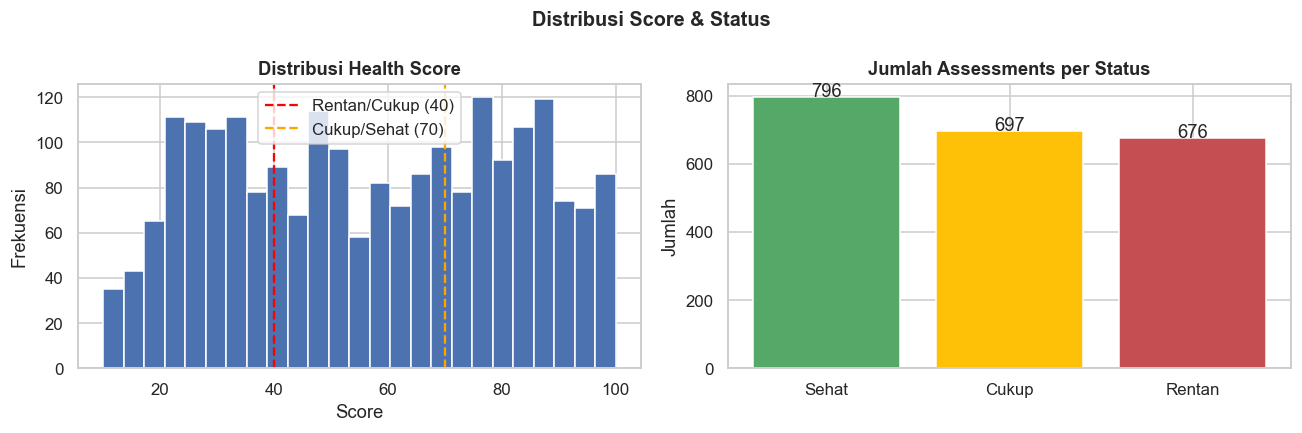

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(assess["score"], bins=25, color="#4C72B0", edgecolor="white")
axes[0].axvline(40, color="red", linestyle="--", label="Rentan/Cukup (40)")
axes[0].axvline(70, color="orange", linestyle="--", label="Cukup/Sehat (70)")
axes[0].set_title("Distribusi Health Score")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Frekuensi")
axes[0].legend()

status_counts = assess["status"].value_counts()
status_colors = {"Rentan": "#C44E52", "Cukup": "#FFC107", "Sehat": "#55A868"}
bar_colors = [status_colors[s] for s in status_counts.index]
axes[1].bar(status_counts.index, status_counts.values, color=bar_colors)
axes[1].set_title("Jumlah Assessments per Status")
axes[1].set_ylabel("Jumlah")
for i, v in enumerate(status_counts.values):
    axes[1].text(i, v + 2, f"{v:,}", ha="center")

plt.suptitle("Distribusi Score & Status", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### 4.3 Tren Score per Bulan

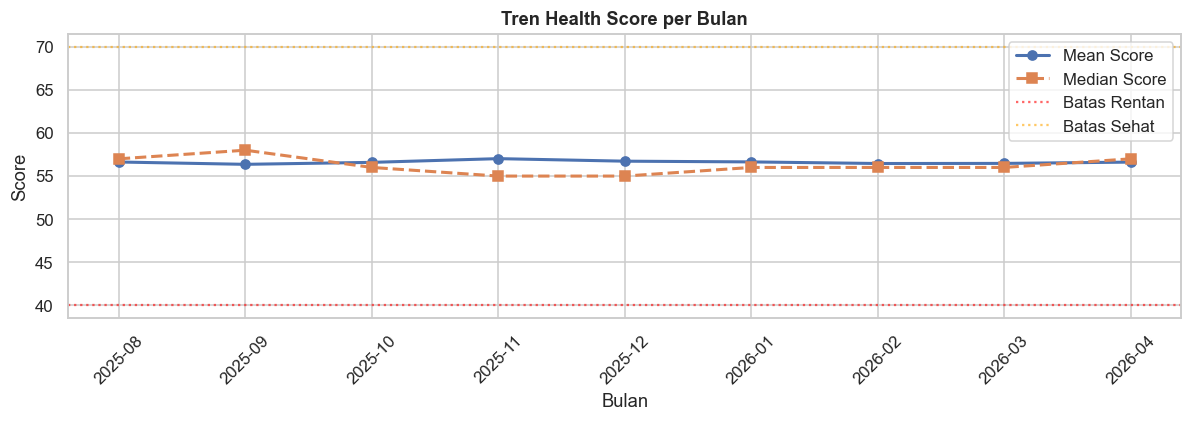

In [30]:
assess["month_period"] = assess["createdAt"].dt.to_period("M")
score_trend = assess.groupby("month_period")["score"].agg(["mean","median"])

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(score_trend.index.astype(str), score_trend["mean"],
        marker="o", label="Mean Score", linewidth=2, color="#4C72B0")
ax.plot(score_trend.index.astype(str), score_trend["median"],
        marker="s", label="Median Score", linewidth=2,
        linestyle="--", color="#DD8452")
ax.axhline(40, color="red", linestyle=":", alpha=0.6, label="Batas Rentan")
ax.axhline(70, color="orange", linestyle=":", alpha=0.6, label="Batas Sehat")
ax.set_title("Tren Health Score per Bulan")
ax.set_xlabel("Bulan")
ax.set_ylabel("Score")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 4.4 Distribusi Assessment per User

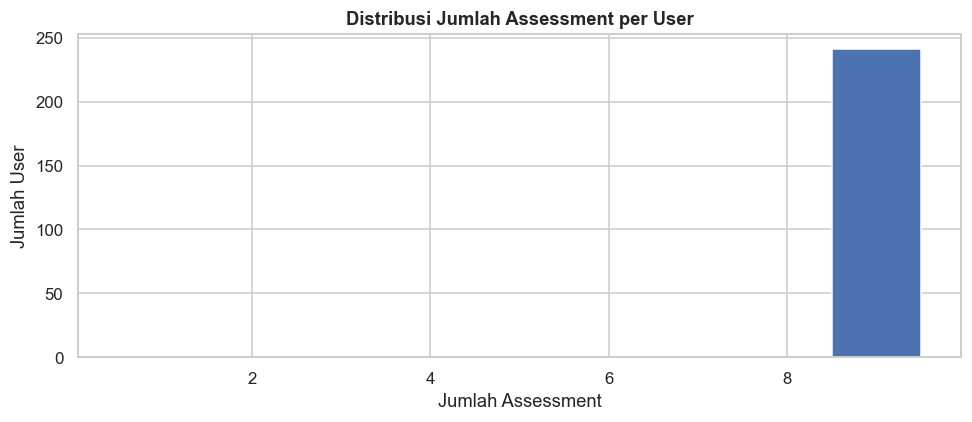

count   241.00
mean      9.00
std       0.00
min       9.00
25%       9.00
50%       9.00
75%       9.00
max       9.00
dtype: float64


In [31]:
assess_per_user = assess.groupby("userId").size()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(assess_per_user, bins=range(1, assess_per_user.max() + 2),
        color="#4C72B0", edgecolor="white", align="left")
ax.set_title("Distribusi Jumlah Assessment per User")
ax.set_xlabel("Jumlah Assessment")
ax.set_ylabel("Jumlah User")
plt.tight_layout()
plt.show()

print(assess_per_user.describe())


---
## 5. Chat Messages

### 5.1 Gambaran Umum

In [32]:
print(chat.shape)
chat.head()


(2322, 5)


,id,userId,role,message,createdAt
0,12687196-70ba-4e6e-85bc-574d3e916268,4015130f-0670-41a8-9503-440a9f71dd79,user,Apa itu reksa dana dan bagaimana cara mulai in...,2025-10-24 19:34:03.242121
1,8abfc392-87d6-43a3-9b89-9c0fa11177c0,4015130f-0670-41a8-9503-440a9f71dd79,assistant,Reksa dana adalah instrumen investasi kolektif...,2025-10-24 19:34:11.242121
2,fcdcf80b-54c6-440d-9e70-79f5017e3862,4015130f-0670-41a8-9503-440a9f71dd79,user,Saya ingin belajar tentang manajemen utang.,2026-02-07 16:40:12.242121
3,14ebd648-5ddb-44fc-b3bd-761e7205e5cb,4015130f-0670-41a8-9503-440a9f71dd79,assistant,Prioritaskan melunasi utang dengan bunga terti...,2026-02-07 16:40:18.242121
4,2ace5621-b30a-4ff4-8838-07eec6e68fbc,4015130f-0670-41a8-9503-440a9f71dd79,user,Gimana cara saya bisa hemat lebih banyak?,2026-05-01 07:07:56.242121


In [33]:
print("Missing values:")
print(chat.isnull().sum())
print()
print("Distribusi role:")
print(chat["role"].value_counts())


Missing values:
id           0
userId       0
role         0
message      0
createdAt    0
dtype: int64

Distribusi role:
role
user         1161
assistant    1161
Name: count, dtype: int64


### 5.2 Pesan Terpopuler

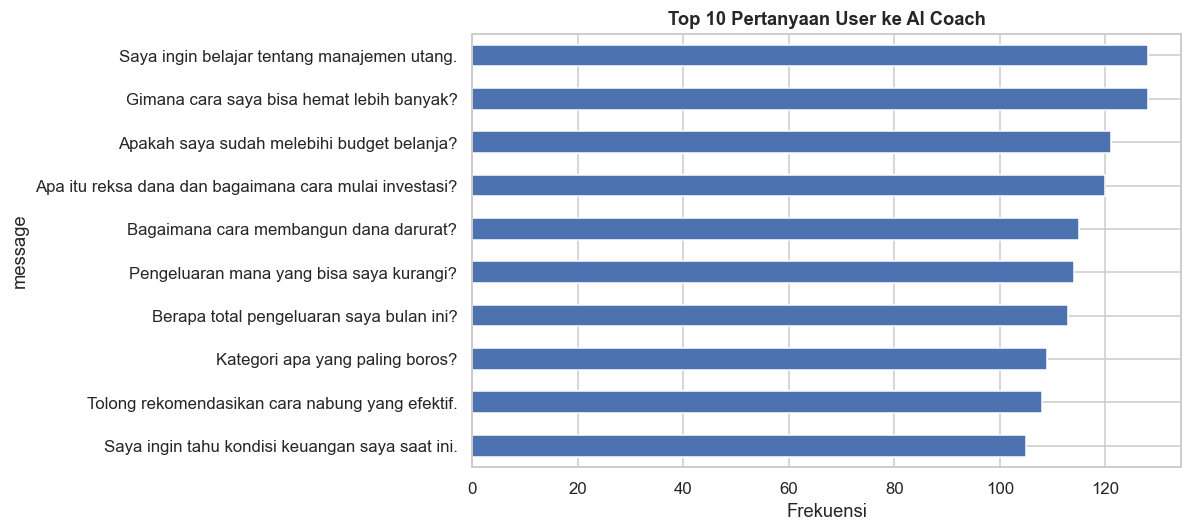

In [34]:
top_user_msg = (chat[chat["role"] == "user"]["message"]
                .value_counts()
                .head(10))

fig, ax = plt.subplots(figsize=(11, 5))
top_user_msg.sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Top 10 Pertanyaan User ke AI Coach")
ax.set_xlabel("Frekuensi")
plt.tight_layout()
plt.show()


### 5.3 Aktivitas Chat per Bulan

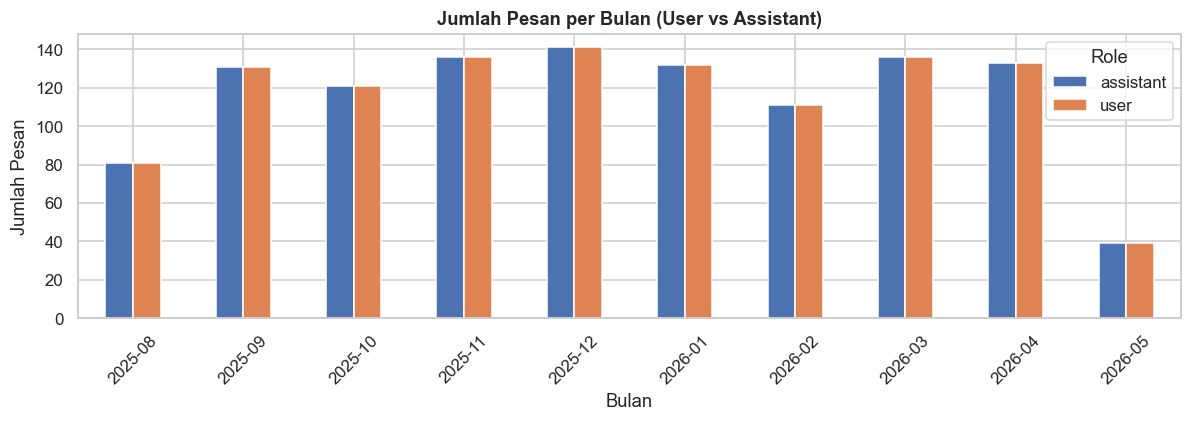

In [35]:
chat["month_period"] = chat["createdAt"].dt.to_period("M")
chat_trend = chat.groupby(["month_period","role"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(11, 4))
chat_trend.plot(kind="bar", ax=ax, color=["#4C72B0","#DD8452"],
                edgecolor="white")
ax.set_title("Jumlah Pesan per Bulan (User vs Assistant)")
ax.set_xlabel("Bulan")
ax.set_ylabel("Jumlah Pesan")
ax.legend(title="Role")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 5.4 Session per User

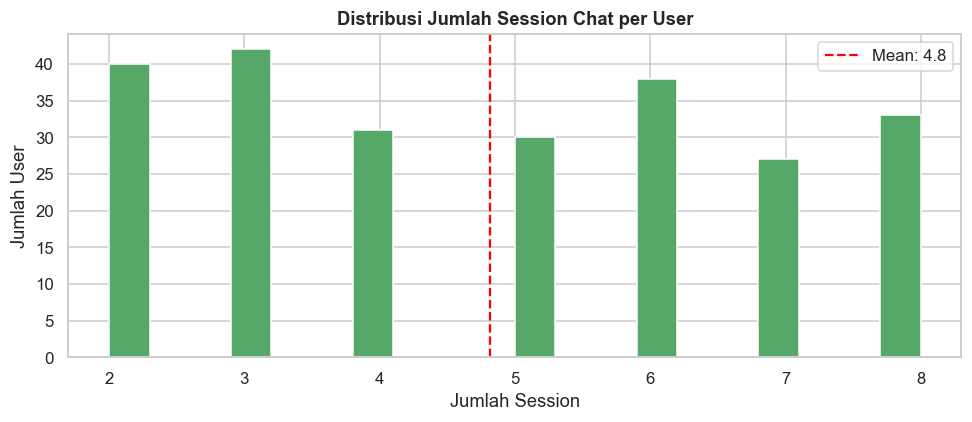

count   241.00
mean      4.82
std       2.04
min       2.00
25%       3.00
50%       5.00
75%       6.00
max       8.00
dtype: float64


In [36]:
# 1 session = 1 pasang pesan (user + assistant)
sessions_per_user = (chat[chat["role"] == "user"]
                     .groupby("userId").size())

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(sessions_per_user, bins=20, color="#55A868", edgecolor="white")
ax.set_title("Distribusi Jumlah Session Chat per User")
ax.set_xlabel("Jumlah Session")
ax.set_ylabel("Jumlah User")
ax.axvline(sessions_per_user.mean(), color="red", linestyle="--",
           label=f"Mean: {sessions_per_user.mean():.1f}")
ax.legend()
plt.tight_layout()
plt.show()

print(sessions_per_user.describe())


---
## 6. Literacy Articles

### 6.1 Gambaran Umum

In [37]:
print(articles.shape)
articles.head()


(38, 7)


,id,title,slug,category,summary,content,status
0,0ffc7f76-f051-447d-a8fb-7f30629d18d6,Kenali Pola Pengeluaran Makanan Kamu,pola-pengeluaran-makanan-1,Makanan,Analisis kebiasaan belanja Makanan dan cara me...,[Konten lengkap artikel tentang Makanan — plac...,published
1,1091e8d7-1afd-44f8-a655-f0ac00fa898e,Tips Hemat Kesehatan Bulanan,hemat-kesehatan-bulanan-2,Kesehatan,Panduan praktis mengelola pengeluaran Kesehata...,[Konten lengkap artikel tentang Kesehatan — pl...,published
2,a9fab684-4ff5-48cb-886f-75068f08b062,Cara Budgeting Transportasi yang Efektif,budgeting-transportasi-efektif-3,Transportasi,Strategi alokasi dana untuk kategori Transport...,[Konten lengkap artikel tentang Transportasi —...,published
3,fa63dfee-7960-4b7f-b89a-248f5654b7f6,Kenali Pola Pengeluaran Makanan Kamu,pola-pengeluaran-makanan-4,Makanan,Analisis kebiasaan belanja Makanan dan cara me...,[Konten lengkap artikel tentang Makanan — plac...,published
4,0d92b860-f7a9-435c-9351-0c0889c42133,Cara Budgeting Pendidikan yang Efektif,budgeting-pendidikan-efektif-5,Pendidikan,Strategi alokasi dana untuk kategori Pendidika...,[Konten lengkap artikel tentang Pendidikan — p...,published


In [38]:
print("Missing values:")
print(articles.isnull().sum())


Missing values:
id          0
title       0
slug        0
category    0
summary     0
content     0
status      0
dtype: int64


### 6.2 Distribusi Artikel per Kategori & Status

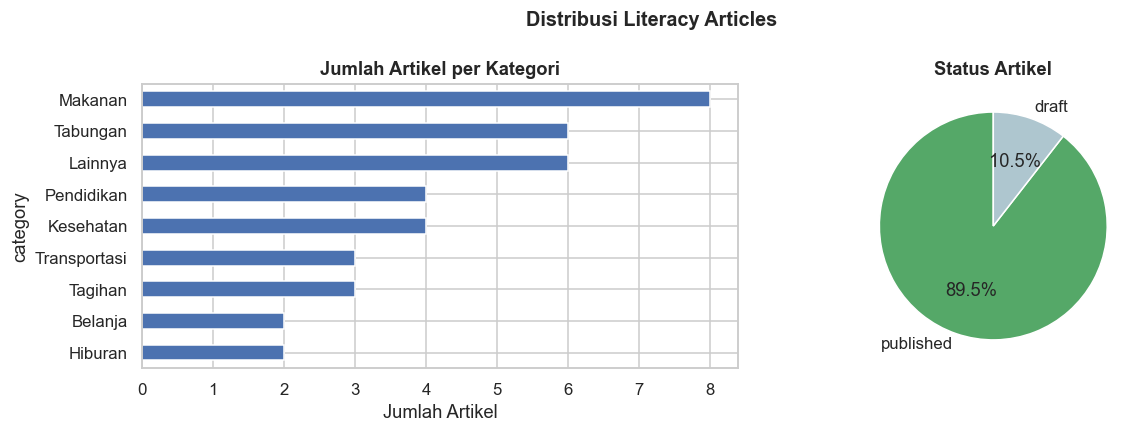

        category     status  count
0        Belanja  published      2
1        Hiburan  published      2
2      Kesehatan      draft      1
3      Kesehatan  published      3
4        Lainnya  published      6
5        Makanan      draft      2
6        Makanan  published      6
7     Pendidikan  published      4
8       Tabungan      draft      1
9       Tabungan  published      5
10       Tagihan  published      3
11  Transportasi  published      3


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cat_counts = articles["category"].value_counts()
cat_counts.sort_values().plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_title("Jumlah Artikel per Kategori")
axes[0].set_xlabel("Jumlah Artikel")

status_counts = articles["status"].value_counts()
axes[1].pie(status_counts.values, labels=status_counts.index,
            autopct="%1.1f%%",
            colors=["#55A868","#AEC6CF"], startangle=90)
axes[1].set_title("Status Artikel")

plt.suptitle("Distribusi Literacy Articles", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(articles.groupby(["category","status"]).size().reset_index(name="count"))


### 6.3 Coverage: Kategori Transaksi vs Artikel

In [40]:
# Cek apakah tiap kategori transaksi punya artikel
tx_cats   = set(tx["category"].unique())
art_cats  = set(articles[articles["status"] == "published"]["category"].unique())

print("Kategori transaksi          :", sorted(tx_cats))
print("Kategori artikel (published):", sorted(art_cats))
print()
print("Kategori transaksi TANPA artikel published:")
missing = tx_cats - art_cats
print(missing if missing else "Semua kategori sudah ter-cover.")


Kategori transaksi          : ['Belanja', 'Hiburan', 'Kesehatan', 'Lainnya', 'Makanan', 'Pendidikan', 'Tabungan', 'Tagihan', 'Transportasi']
Kategori artikel (published): ['Belanja', 'Hiburan', 'Kesehatan', 'Lainnya', 'Makanan', 'Pendidikan', 'Tabungan', 'Tagihan', 'Transportasi']

Kategori transaksi TANPA artikel published:
Semua kategori sudah ter-cover.


---
## 7. User Monthly Summary

### 7.1 Gambaran Umum

In [41]:
print(monthly.shape)
monthly.head()


(2169, 11)


,userId,year,month,totalIncome,totalExpense,netCashflow,expenseIncomeRatio,transactionCount,topExpenseCategory,healthScore,healthStatus
0,4015130f-0670-41a8-9503-440a9f71dd79,2025,8,5929998,4324169,1605829,0.73,56,Tagihan,34,Rentan
1,4015130f-0670-41a8-9503-440a9f71dd79,2025,9,7337297,4114628,3222669,0.56,53,Tagihan,34,Rentan
2,4015130f-0670-41a8-9503-440a9f71dd79,2025,10,5952090,4637567,1314523,0.78,58,Tagihan,34,Rentan
3,4015130f-0670-41a8-9503-440a9f71dd79,2025,11,5867531,4758345,1109186,0.81,49,Tagihan,34,Rentan
4,4015130f-0670-41a8-9503-440a9f71dd79,2025,12,7613402,4823329,2790073,0.63,63,Makanan,34,Rentan


In [42]:
print("Missing values:")
print(monthly.isnull().sum())
print()
monthly[["totalIncome","totalExpense","netCashflow","expenseIncomeRatio"]].describe().T


Missing values:
userId                0
year                  0
month                 0
totalIncome           0
totalExpense          0
netCashflow           0
expenseIncomeRatio    0
transactionCount      0
topExpenseCategory    0
healthScore           0
healthStatus          0
dtype: int64



,count,mean,std,min,25%,50%,75%,max
totalIncome,"2,169.00","7,482,524.75","3,717,069.17","3,222,133.00","5,022,449.00","6,300,598.00","8,621,902.00","26,568,314.00"
totalExpense,"2,169.00","4,739,339.82","650,171.90","2,765,121.00","4,286,386.00","4,748,111.00","5,181,315.00","6,846,577.00"
netCashflow,"2,169.00","2,743,184.93","3,762,688.30","-2,976,458.00","286,208.00","1,653,212.00","3,937,905.00","22,440,256.00"
expenseIncomeRatio,"2,169.00",0.75,0.29,0.15,0.54,0.73,0.94,1.85


### 7.2 Distribusi Net Cashflow

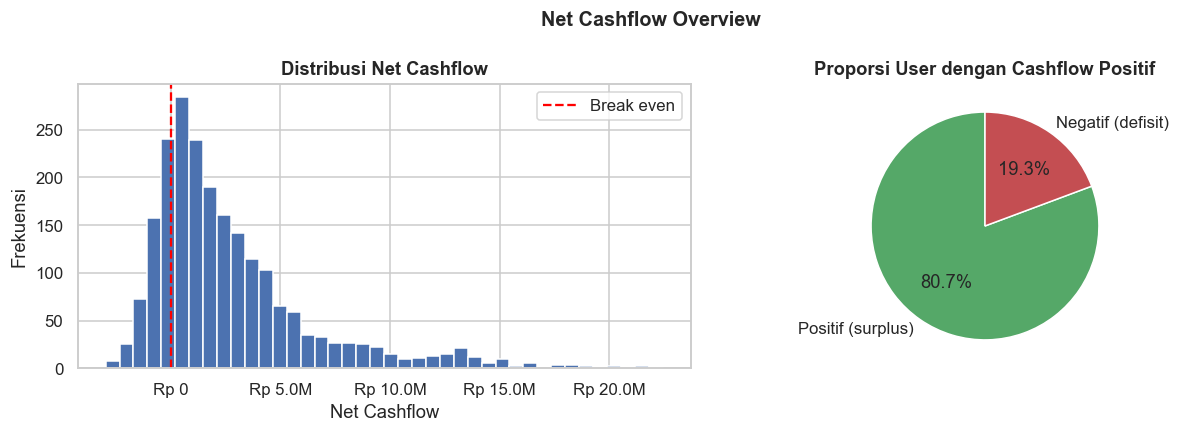

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(monthly["netCashflow"], bins=40, color="#4C72B0", edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--", label="Break even")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_rupiah))
axes[0].set_title("Distribusi Net Cashflow")
axes[0].set_xlabel("Net Cashflow")
axes[0].set_ylabel("Frekuensi")
axes[0].legend()

pct_positive = (monthly["netCashflow"] > 0).mean() * 100
axes[1].pie([pct_positive, 100 - pct_positive],
            labels=["Positif (surplus)", "Negatif (defisit)"],
            autopct="%1.1f%%",
            colors=["#55A868","#C44E52"], startangle=90)
axes[1].set_title("Proporsi User dengan Cashflow Positif")

plt.suptitle("Net Cashflow Overview", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### 7.3 Tren Income & Expense per Bulan (Agregat)

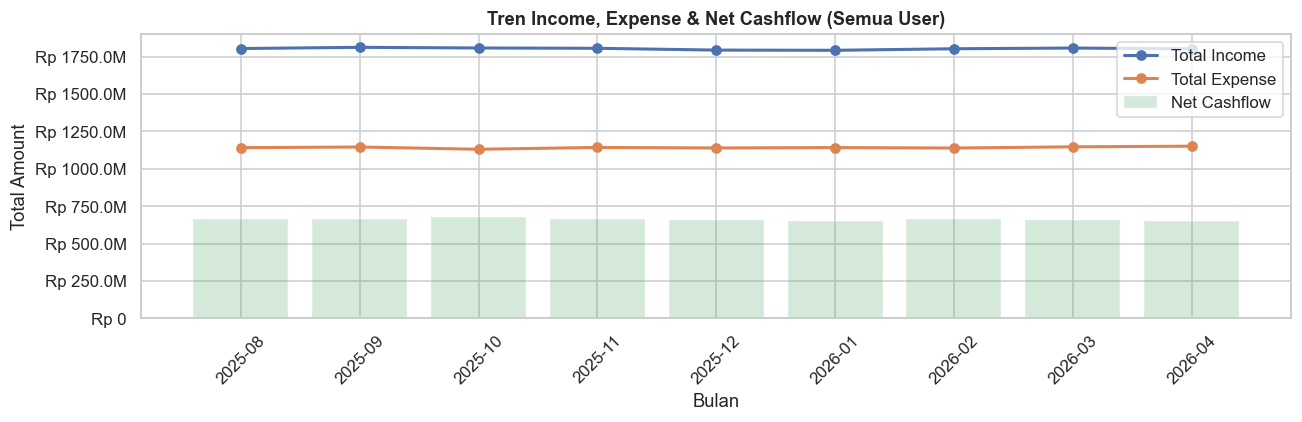

In [44]:
trend = monthly.groupby(["year","month"])[["totalIncome","totalExpense","netCashflow"]].sum()
trend.index = [f"{y}-{m:02d}" for y, m in trend.index]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(trend.index, trend["totalIncome"], marker="o", label="Total Income",
        linewidth=2, color="#4C72B0")
ax.plot(trend.index, trend["totalExpense"], marker="o", label="Total Expense",
        linewidth=2, color="#DD8452")
ax.bar(trend.index, trend["netCashflow"], alpha=0.25,
       color=["#55A868" if v >= 0 else "#C44E52" for v in trend["netCashflow"]],
       label="Net Cashflow")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_rupiah))
ax.set_title("Tren Income, Expense & Net Cashflow (Semua User)")
ax.set_xlabel("Bulan")
ax.set_ylabel("Total Amount")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 7.4 Expense-Income Ratio

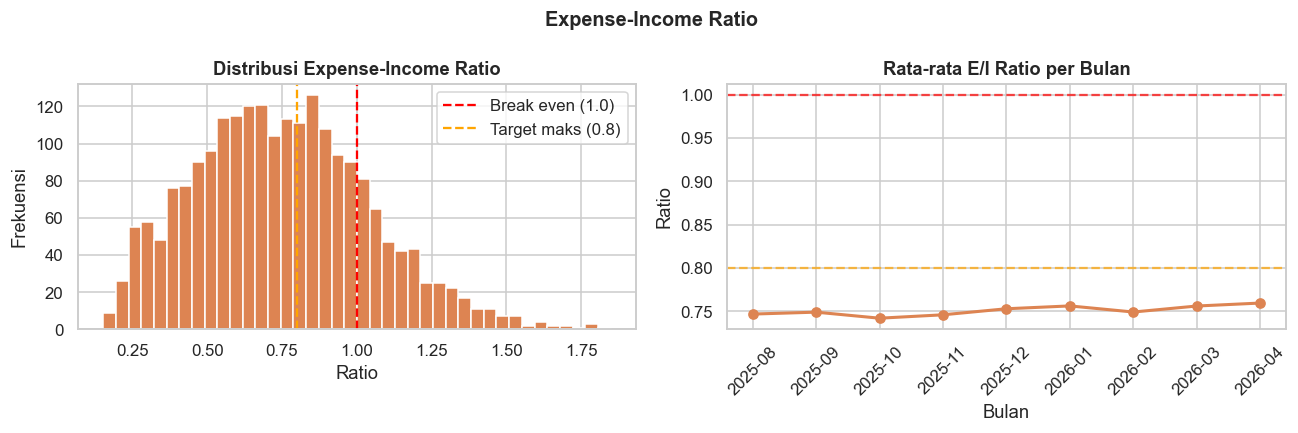

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ratio_clean = monthly["expenseIncomeRatio"].dropna().clip(upper=2)
axes[0].hist(ratio_clean, bins=40, color="#DD8452", edgecolor="white")
axes[0].axvline(1.0, color="red", linestyle="--", label="Break even (1.0)")
axes[0].axvline(0.8, color="orange", linestyle="--", label="Target maks (0.8)")
axes[0].set_title("Distribusi Expense-Income Ratio")
axes[0].set_xlabel("Ratio")
axes[0].set_ylabel("Frekuensi")
axes[0].legend()

# Ratio per bulan
ratio_monthly = monthly.groupby(["year","month"])["expenseIncomeRatio"].mean()
ratio_monthly.index = [f"{y}-{m:02d}" for y, m in ratio_monthly.index]
axes[1].plot(ratio_monthly.index, ratio_monthly.values,
             marker="o", linewidth=2, color="#DD8452")
axes[1].axhline(1.0, color="red", linestyle="--", alpha=0.7)
axes[1].axhline(0.8, color="orange", linestyle="--", alpha=0.7)
axes[1].set_title("Rata-rata E/I Ratio per Bulan")
axes[1].set_xlabel("Bulan")
axes[1].set_ylabel("Ratio")
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.suptitle("Expense-Income Ratio", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### 7.5 Top Expense Category per Bulan

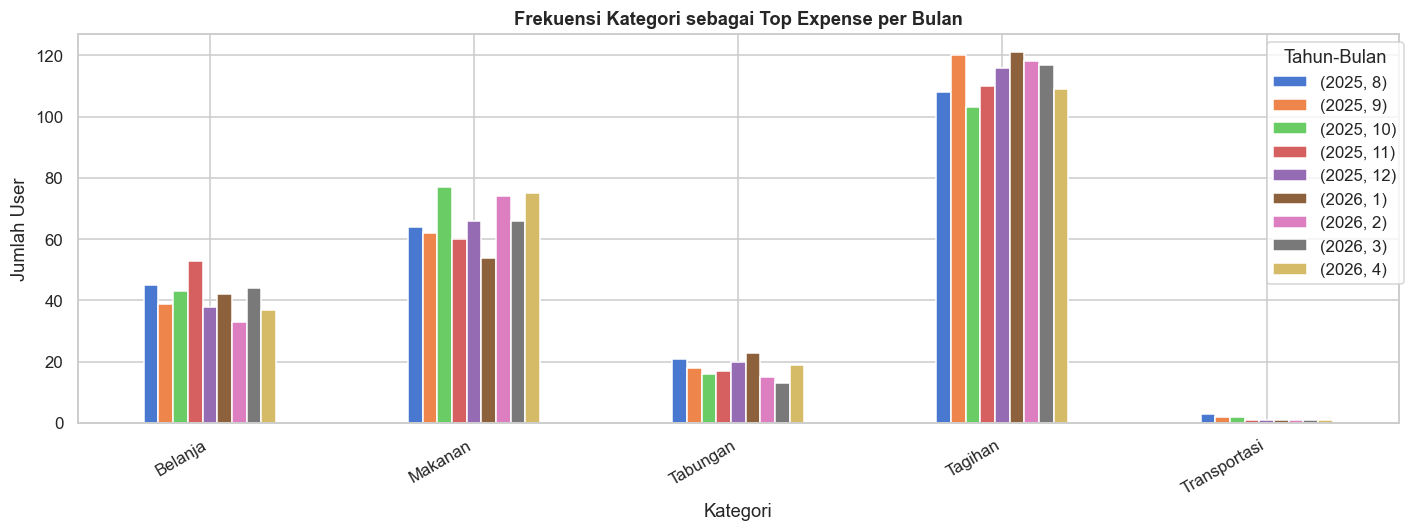

In [46]:
top_cat_monthly = (monthly.groupby(["year","month","topExpenseCategory"])
                   .size()
                   .reset_index(name="count"))

pivot_top = top_cat_monthly.pivot_table(
    index="topExpenseCategory",
    columns=["year","month"],
    values="count",
    fill_value=0
)

fig, ax = plt.subplots(figsize=(13, 5))
pivot_top.plot(kind="bar", ax=ax, edgecolor="white")
ax.set_title("Frekuensi Kategori sebagai Top Expense per Bulan")
ax.set_xlabel("Kategori")
ax.set_ylabel("Jumlah User")
ax.legend(title="Tahun-Bulan", bbox_to_anchor=(1.01, 1))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### 7.6 Health Score vs Net Cashflow

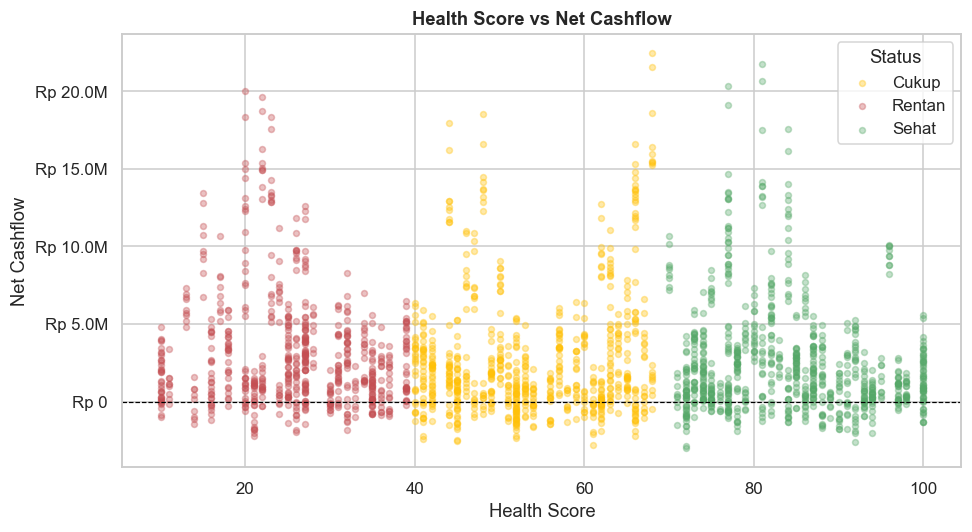

               count          mean           std            min         25%  \
healthStatus                                                                  
Cukup         Rp 711  Rp 2,716,135  Rp 4,025,910  Rp -2,835,986  Rp 144,767   
Rentan        Rp 648  Rp 3,092,659  Rp 3,747,554  Rp -2,200,363  Rp 593,868   
Sehat         Rp 810  Rp 2,487,349  Rp 3,510,053  Rp -2,976,458  Rp 249,315   

                       50%           75%            max  
healthStatus                                             
Cukup         Rp 1,492,312  Rp 3,785,705  Rp 22,440,256  
Rentan        Rp 2,027,994  Rp 4,539,969  Rp 20,048,450  
Sehat         Rp 1,553,052  Rp 3,472,389  Rp 21,759,114  


C:\Users\Hp\AppData\Local\Temp\ipykernel_15176\2311559257.py:19: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  .applymap(lambda x: f"Rp {x:,.0f}"))


In [47]:
fig, ax = plt.subplots(figsize=(9, 5))

status_colors = {"Rentan": "#C44E52", "Cukup": "#FFC107", "Sehat": "#55A868"}
for status, grp in monthly.groupby("healthStatus"):
    ax.scatter(grp["healthScore"], grp["netCashflow"],
               alpha=0.35, s=15, label=status,
               color=status_colors.get(status, "gray"))

ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_rupiah))
ax.set_title("Health Score vs Net Cashflow")
ax.set_xlabel("Health Score")
ax.set_ylabel("Net Cashflow")
ax.legend(title="Status")
plt.tight_layout()
plt.show()

print(monthly.groupby("healthStatus")["netCashflow"].describe()
      .applymap(lambda x: f"Rp {x:,.0f}"))


---
## 8. Category Spending Summary

### 8.1 Gambaran Umum

In [48]:
print(cat_summary.shape)
cat_summary.head()


(18078, 9)


,userId,year,month,category,expenseAmount,transactionCount,limitAmount,budgetStatus,usagePercent
0,0083f21a-4775-4d0c-b77a-a39c82812c19,2025,8,Belanja,487892,2,"760,776.00",safe,64.10
1,0083f21a-4775-4d0c-b77a-a39c82812c19,2025,8,Hiburan,61460,2,"888,618.00",safe,6.90
2,0083f21a-4775-4d0c-b77a-a39c82812c19,2025,8,Lainnya,490791,3,"677,780.00",safe,72.40
3,0083f21a-4775-4d0c-b77a-a39c82812c19,2025,8,Makanan,805900,22,"161,142.00",over,500.10
4,0083f21a-4775-4d0c-b77a-a39c82812c19,2025,8,Pendidikan,620794,2,"740,857.00",warning,83.80


In [49]:
print("Missing values:")
print(cat_summary.isnull().sum())
print()
cat_summary[["expenseAmount","transactionCount","limitAmount","usagePercent"]].describe().T


Missing values:
userId                 0
year                   0
month                  0
category               0
expenseAmount          0
transactionCount       0
limitAmount         4163
budgetStatus        4163
usagePercent        4163
dtype: int64



,count,mean,std,min,25%,50%,75%,max
expenseAmount,"18,078.00","568,626.40","359,140.06","15,121.00","274,320.00","486,941.00","827,662.50","1,990,403.00"
transactionCount,"18,078.00",6.88,8.55,1.00,2.00,3.00,5.00,35.00
limitAmount,"13,915.00","998,786.69","704,646.72","105,796.00","511,742.00","848,953.00","1,252,697.00","5,129,651.00"
usagePercent,"13,915.00",91.36,100.78,0.80,28.50,59.30,114.35,"1,029.10"


### 8.2 Rata-rata Spending per Kategori

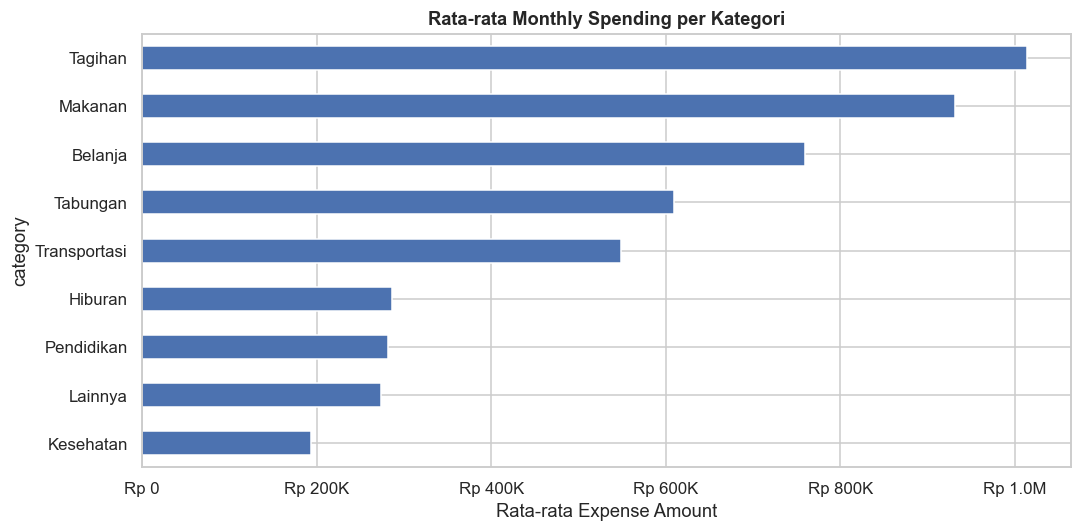

In [50]:
avg_spending = cat_summary.groupby("category")["expenseAmount"].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
avg_spending.plot(kind="barh", ax=ax, color="#4C72B0")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_rupiah))
ax.set_title("Rata-rata Monthly Spending per Kategori")
ax.set_xlabel("Rata-rata Expense Amount")
plt.tight_layout()
plt.show()


### 8.3 Heatmap Spending Kategori per Bulan

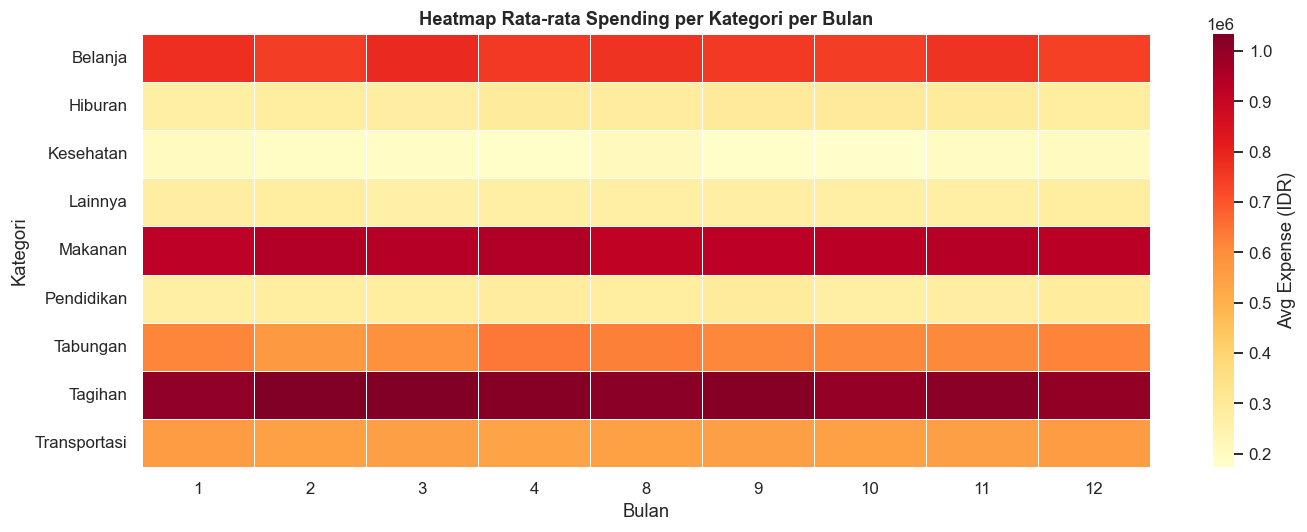

In [51]:
heatmap_data = cat_summary.groupby(["month","category"])["expenseAmount"].mean().unstack()

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(heatmap_data.T, fmt=".0f", cmap="YlOrRd", ax=ax,
            linewidths=0.5,
            cbar_kws={"label": "Avg Expense (IDR)"})
ax.set_title("Heatmap Rata-rata Spending per Kategori per Bulan")
ax.set_xlabel("Bulan")
ax.set_ylabel("Kategori")
plt.tight_layout()
plt.show()


### 8.4 Distribusi Usage Percent per Kategori

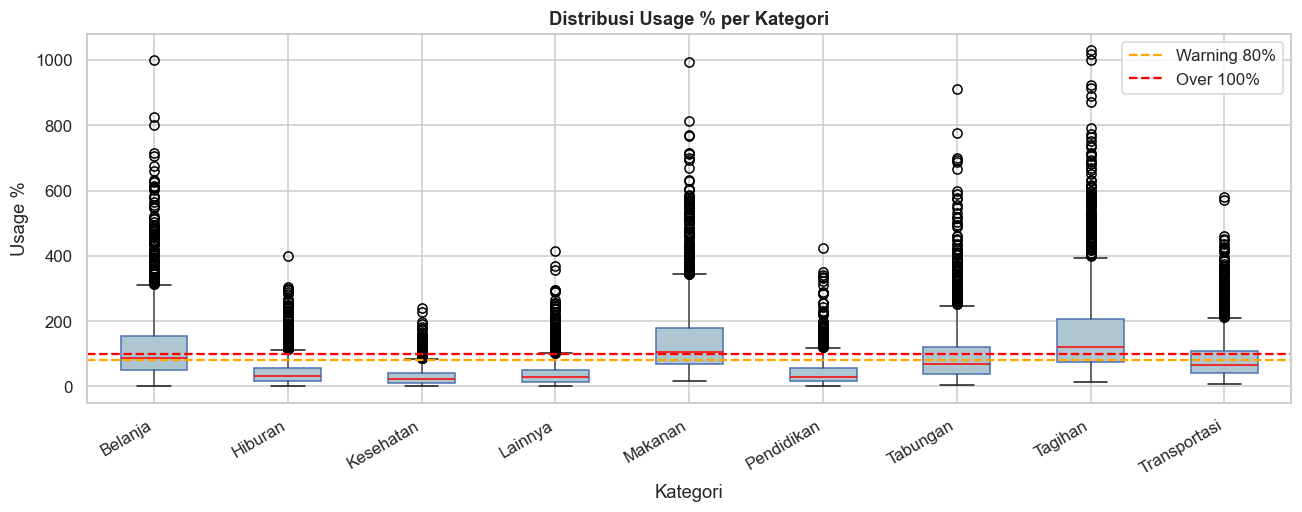

In [52]:
fig, ax = plt.subplots(figsize=(12, 5))
cat_summary.boxplot(column="usagePercent", by="category",
                    ax=ax, patch_artist=True,
                    boxprops=dict(facecolor="#AEC6CF", color="#4C72B0"),
                    medianprops=dict(color="red"))
ax.axhline(80, color="orange", linestyle="--", label="Warning 80%")
ax.axhline(100, color="red", linestyle="--", label="Over 100%")
ax.set_title("Distribusi Usage % per Kategori")
ax.set_xlabel("Kategori")
ax.set_ylabel("Usage %")
plt.suptitle("")
plt.xticks(rotation=30, ha="right")
ax.legend()
plt.tight_layout()
plt.show()


---
## 9. NLP Training Dataset

### 9.1 Gambaran Umum

In [53]:
print(nlp.shape)
nlp.head()


(75973, 20)


,rawText,cleanText,detectedAmount,actualAmount,detectedType,actualType,detectedCategory,actualCategory,confidence,isCorrect,nlpCategoryCorrect,nlpTypeCorrect,correctionNeeded,correctedCategory,correctedType,isNeed,isWant,isRecurring,isImpulse,isOverBudgetRisk
0,15k buat kopi,15k buat kopi,38301,35942,expense,expense,Makanan,Makanan,0.73,True,True,True,False,NaN,NaN,True,False,False,False,True
1,kopi susu lg,kopi susu lg,48055,48246,expense,expense,Makanan,Makanan,0.80,True,True,True,False,NaN,NaN,True,False,False,False,True
2,kopi susu lg,kopi susu lg,21746,22076,expense,expense,Makanan,Makanan,0.74,True,True,True,False,NaN,NaN,True,False,False,False,False
3,beli gorgn dpn rmh,beli gorgn dpn rmh,41490,43185,expense,expense,Makanan,Makanan,0.77,True,True,True,False,NaN,NaN,True,False,False,False,False
4,gopay buat pesan makan,gopay buat pesan makan,50546,51955,expense,expense,Makanan,Makanan,0.83,True,True,True,False,NaN,NaN,True,False,False,False,False


In [54]:
print("Missing values:")
print(nlp.isnull().sum())


Missing values:
rawText                   0
cleanText                 0
detectedAmount            0
actualAmount              0
detectedType              0
actualType                0
detectedCategory          0
actualCategory            0
confidence                0
isCorrect                 0
nlpCategoryCorrect        0
nlpTypeCorrect            0
correctionNeeded          0
correctedCategory     62127
correctedType         69102
isNeed                    0
isWant                    0
isRecurring               0
isImpulse                 0
isOverBudgetRisk          0
dtype: int64


### 9.2 Akurasi Model NLP

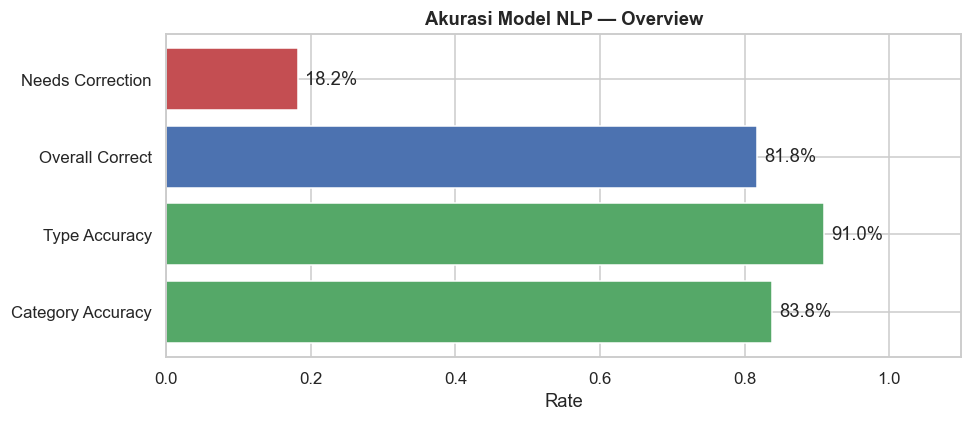

  Category Accuracy     : 83.8%
  Type Accuracy         : 91.0%
  Overall Correct       : 81.8%
  Needs Correction      : 18.2%


In [55]:
metrics = {
    "Category Accuracy" : nlp["nlpCategoryCorrect"].mean(),
    "Type Accuracy"     : nlp["nlpTypeCorrect"].mean(),
    "Overall Correct"   : nlp["isCorrect"].mean(),
    "Needs Correction"  : nlp["correctionNeeded"].mean(),
}

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(list(metrics.keys()), list(metrics.values()),
               color=["#55A868","#55A868","#4C72B0","#C44E52"])
ax.set_xlim(0, 1.1)
ax.set_title("Akurasi Model NLP — Overview")
ax.set_xlabel("Rate")
for i, (k, v) in enumerate(metrics.items()):
    ax.text(v + 0.01, i, f"{v:.1%}", va="center")
plt.tight_layout()
plt.show()

for k, v in metrics.items():
    print(f"  {k:<22}: {v:.1%}")


### 9.3 Akurasi Kategori per Aktual Kategori

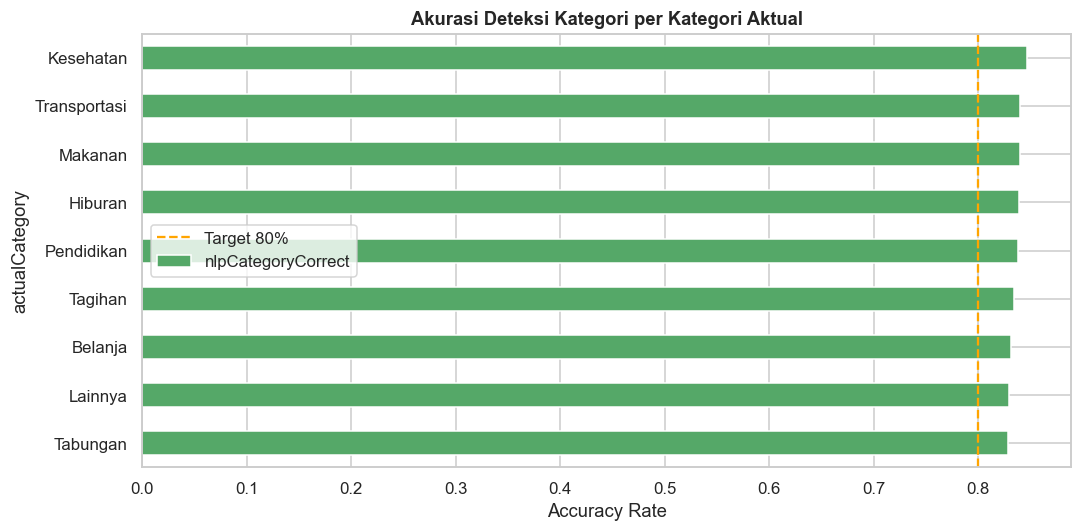

In [56]:
acc_by_cat = nlp.groupby("actualCategory")["nlpCategoryCorrect"].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = ["#C44E52" if v < 0.8 else "#55A868" for v in acc_by_cat.values]
acc_by_cat.plot(kind="barh", ax=ax, color=colors_bar)
ax.axvline(0.8, color="orange", linestyle="--", label="Target 80%")
ax.set_title("Akurasi Deteksi Kategori per Kategori Aktual")
ax.set_xlabel("Accuracy Rate")
ax.legend()
plt.tight_layout()
plt.show()


### 9.4 Confusion Matrix Kategori

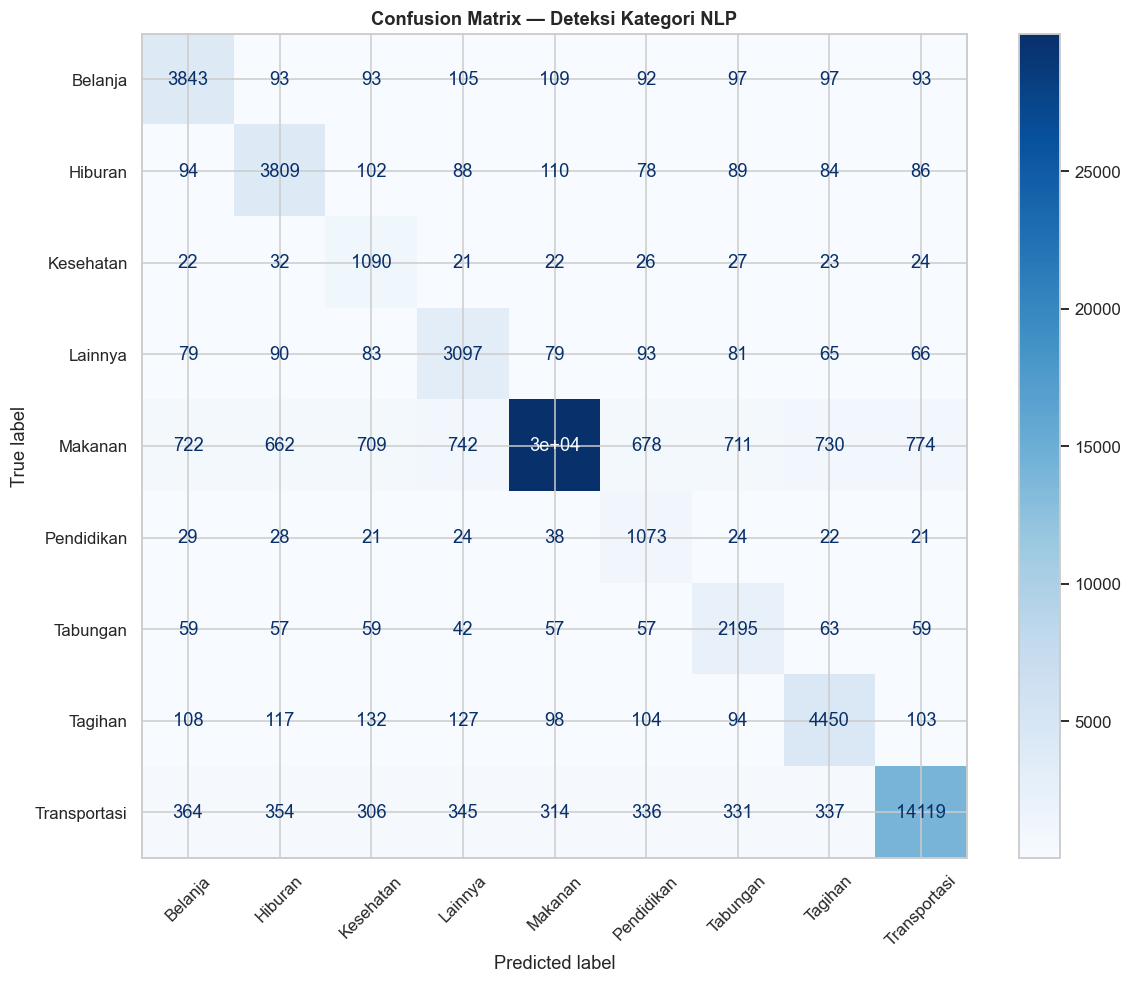

In [57]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cats = sorted(nlp["actualCategory"].unique())
cm = confusion_matrix(nlp["actualCategory"], nlp["detectedCategory"], labels=cats)

fig, ax = plt.subplots(figsize=(11, 9))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cats)
disp.plot(ax=ax, cmap="Blues", colorbar=True, xticks_rotation=45)
ax.set_title("Confusion Matrix — Deteksi Kategori NLP")
plt.tight_layout()
plt.show()


### 9.5 Confidence vs Akurasi

C:\Users\Hp\AppData\Local\Temp\ipykernel_15176\904079883.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  acc_by_conf = nlp.groupby("conf_bucket")["nlpCategoryCorrect"].mean()


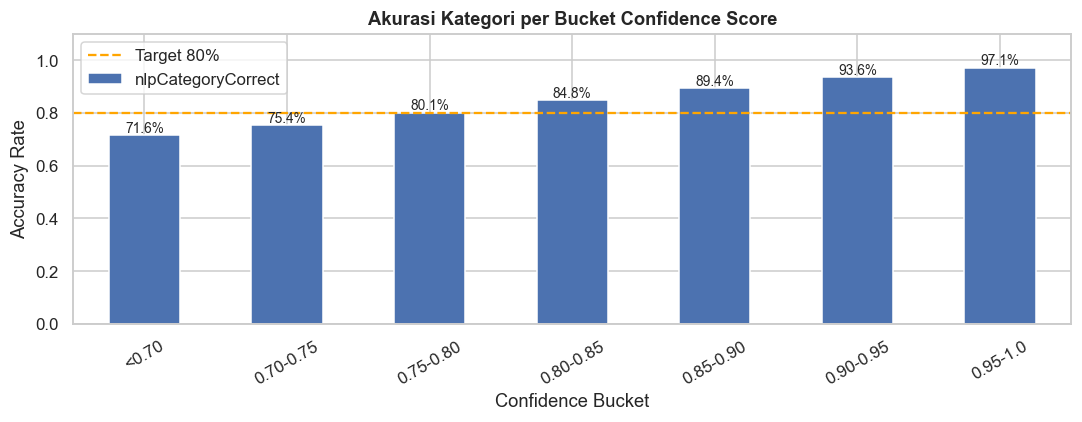

In [58]:
# Bagi confidence ke dalam bucket
nlp["conf_bucket"] = pd.cut(nlp["confidence"],
                             bins=[0, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0],
                             labels=["<0.70","0.70-0.75","0.75-0.80",
                                     "0.80-0.85","0.85-0.90","0.90-0.95","0.95-1.0"])

acc_by_conf = nlp.groupby("conf_bucket")["nlpCategoryCorrect"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
acc_by_conf.plot(kind="bar", ax=ax, color="#4C72B0", edgecolor="white")
ax.axhline(0.8, color="orange", linestyle="--", label="Target 80%")
ax.set_title("Akurasi Kategori per Bucket Confidence Score")
ax.set_xlabel("Confidence Bucket")
ax.set_ylabel("Accuracy Rate")
ax.set_ylim(0, 1.1)
ax.legend()
for i, v in enumerate(acc_by_conf.values):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center", fontsize=9)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### 9.6 Distribusi Label Supervised

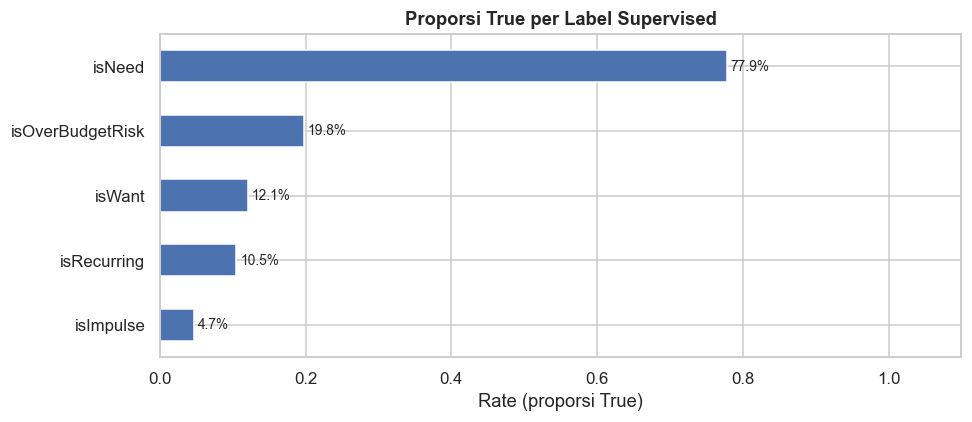

isNeed              77.9%
isWant              12.1%
isRecurring         10.5%
isImpulse            4.7%
isOverBudgetRisk    19.8%
dtype: object


In [59]:
label_cols = ["isNeed","isWant","isRecurring","isImpulse","isOverBudgetRisk"]
label_rates = nlp[label_cols].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
label_rates.plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Proporsi True per Label Supervised")
ax.set_xlabel("Rate (proporsi True)")
for i, v in enumerate(label_rates.values):
    ax.text(v + 0.005, i, f"{v:.1%}", va="center", fontsize=9)
ax.set_xlim(0, 1.1)
plt.tight_layout()
plt.show()

print(nlp[label_cols].mean().apply(lambda x: f"{x:.1%}"))


---
## 10. Cross-Dataset Analysis

### 10.1 Health Score vs Budget Compliance

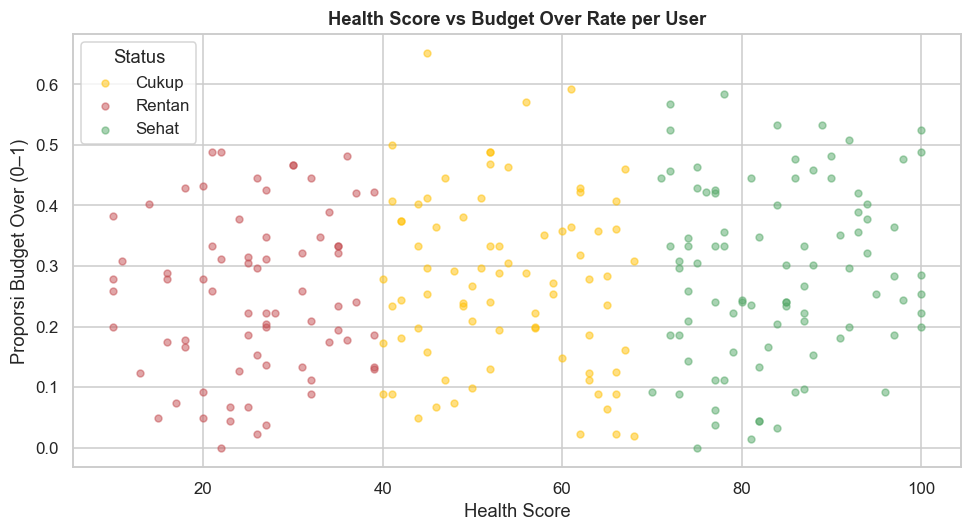

Korelasi Health Score vs Over Rate: 0.114


In [60]:
# Join assessment score dengan budget status per user
latest_assess = (assess.sort_values("createdAt")
                 .groupby("userId")[["score","status"]]
                 .last()
                 .reset_index())

budget_compliance = (budgets.groupby("userId")["budgetStatus"]
                     .apply(lambda x: (x == "over").mean())
                     .reset_index(name="over_rate"))

merged = latest_assess.merge(budget_compliance, on="userId")

fig, ax = plt.subplots(figsize=(9, 5))
status_colors = {"Rentan": "#C44E52", "Cukup": "#FFC107", "Sehat": "#55A868"}
for status, grp in merged.groupby("status"):
    ax.scatter(grp["score"], grp["over_rate"],
               alpha=0.5, s=20, label=status,
               color=status_colors.get(status, "gray"))

ax.set_title("Health Score vs Budget Over Rate per User")
ax.set_xlabel("Health Score")
ax.set_ylabel("Proporsi Budget Over (0–1)")
ax.legend(title="Status")
plt.tight_layout()
plt.show()

print("Korelasi Health Score vs Over Rate:",
      merged[["score","over_rate"]].corr().iloc[0,1].round(3))


### 10.2 Top Spending Category vs Artikel yang Tersedia

Kategori | Spending Rank | Artikel Tersedia
              spending_rank  artikel_tersedia
category                                     
Tagihan                   1                 3
Makanan                   2                 6
Belanja                   3                 2
Tabungan                  4                 5
Transportasi              5                 3
Hiburan                   6                 2
Lainnya                   7                 6
Pendidikan                8                 4
Kesehatan                 9                 3


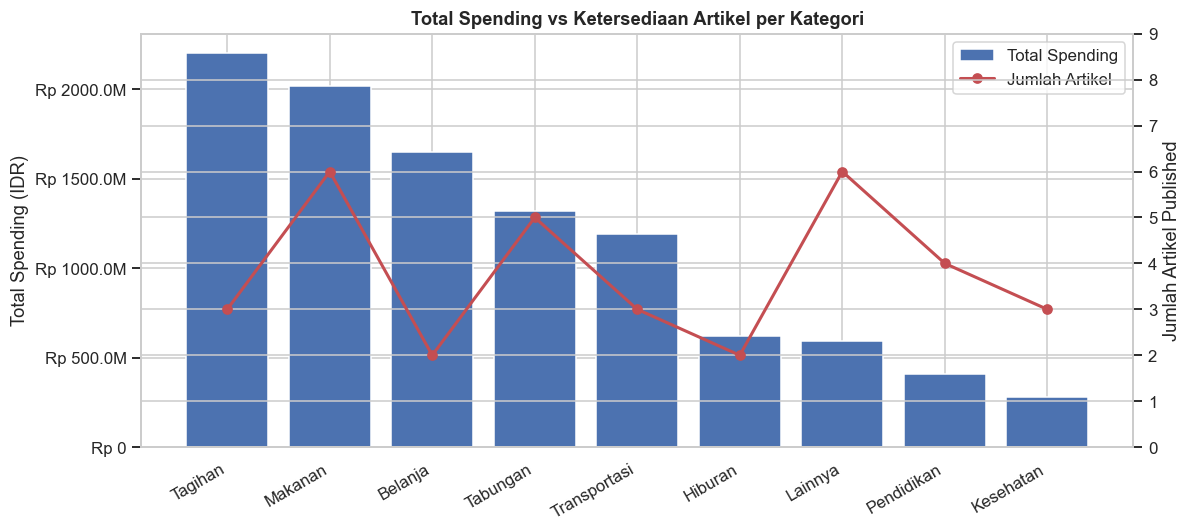

In [61]:
top_cats = (tx[tx["type"] == "expense"]
            .groupby("category")["amount"].sum()
            .sort_values(ascending=False))

art_published = articles[articles["status"] == "published"]["category"].value_counts()

compare = pd.DataFrame({
    "total_spending": top_cats,
    "artikel_tersedia": art_published
}).fillna(0).astype({"artikel_tersedia": int})

compare["spending_rank"] = compare["total_spending"].rank(ascending=False).astype(int)
compare = compare.sort_values("spending_rank")

print("Kategori | Spending Rank | Artikel Tersedia")
print(compare[["spending_rank","artikel_tersedia"]].to_string())

fig, ax1 = plt.subplots(figsize=(11, 5))
x = range(len(compare))
ax1.bar(x, compare["total_spending"], color="#4C72B0", label="Total Spending")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_rupiah))
ax1.set_ylabel("Total Spending (IDR)")

ax2 = ax1.twinx()
ax2.plot(x, compare["artikel_tersedia"], marker="o",
         color="#C44E52", linewidth=2, label="Jumlah Artikel")
ax2.set_ylabel("Jumlah Artikel Published")
ax2.set_ylim(0, compare["artikel_tersedia"].max() + 3)

ax1.set_xticks(list(x))
ax1.set_xticklabels(compare.index, rotation=30, ha="right")
ax1.set_title("Total Spending vs Ketersediaan Artikel per Kategori")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.tight_layout()
plt.show()


### 10.3 Income Level vs Health Score

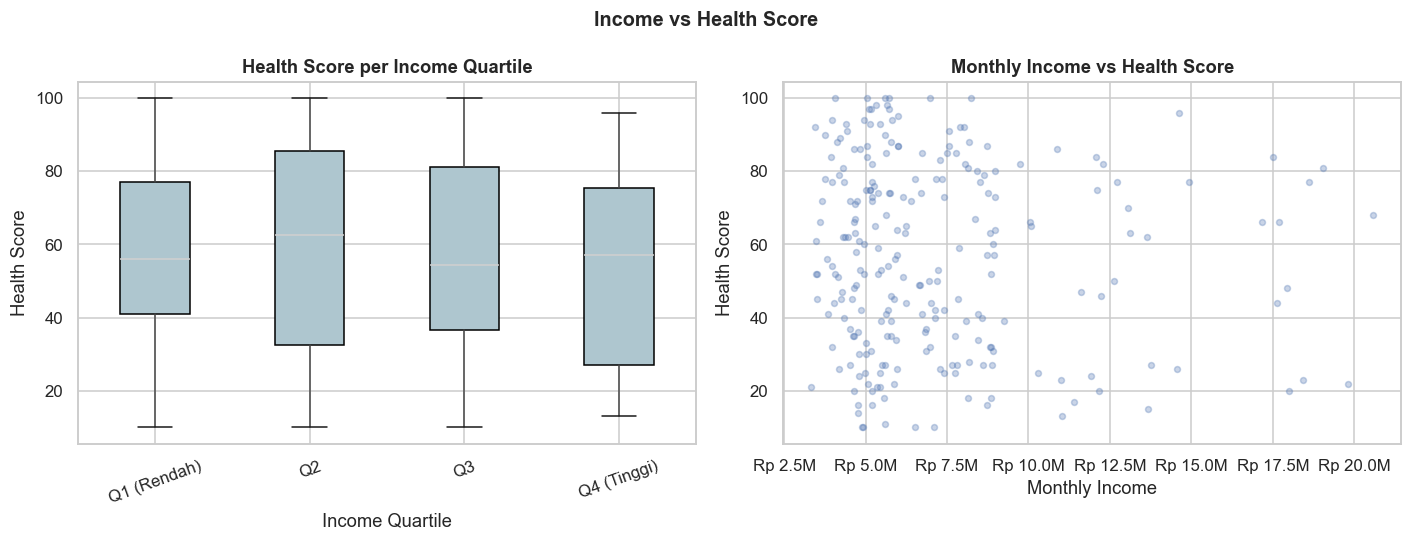

Korelasi Income vs Health Score: -0.067


In [62]:
user_income = users[["id","monthlyIncome"]].rename(columns={"id":"userId"})
merged_inc = latest_assess.merge(user_income, on="userId")

# Bagi income ke quartile
merged_inc["income_quartile"] = pd.qcut(
    merged_inc["monthlyIncome"], q=4,
    labels=["Q1 (Rendah)","Q2","Q3","Q4 (Tinggi)"]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

merged_inc.boxplot(column="score", by="income_quartile", ax=axes[0],
                   patch_artist=True,
                   boxprops=dict(facecolor="#AEC6CF"))
axes[0].set_title("Health Score per Income Quartile")
axes[0].set_xlabel("Income Quartile")
axes[0].set_ylabel("Health Score")
plt.sca(axes[0])
plt.xticks(rotation=20)

axes[1].scatter(merged_inc["monthlyIncome"], merged_inc["score"],
                alpha=0.3, s=15, color="#4C72B0")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_rupiah))
axes[1].set_title("Monthly Income vs Health Score")
axes[1].set_xlabel("Monthly Income")
axes[1].set_ylabel("Health Score")

plt.suptitle("Income vs Health Score", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Korelasi Income vs Health Score:",
      merged_inc[["monthlyIncome","score"]].corr().iloc[0,1].round(3))
